# Chapter 2: Linking PDV and SV Models (corrected numerics)

This notebook reproduces every number, table and figure of Section 4 and
Appendices C–D of Chapter 2. 

### Method summary

This notebook implements the filter exactly as described in the thesis.

| | Implementation |
|---|---|
| Filter order | correction with $Y_{t_n}$, then prediction (Algorithm `alg:ADF1`) |
| $\psi$ | $1-\kappa h+\tfrac{1}{2}\rho\xi h$ |
| Predicted mean $\le 0$ | that step is predicted without the leverage term (Remark `rem:leveragefallback`); the number of such steps is reported and is 0 in every run |
| $\mu$ | true value in simulation; in-sample mean log-return for real data, held fixed |
| Initial density | Inverse-Gamma with shape $\alpha_{t_0\mid t_0}=3>\tfrac{5}{2}$ |
| Simulator | Euler scheme with full truncation ($\nu^+$ in every coefficient) and $(Z^{(1)}_n,Z^{(2)}_n)$ correlated at the same step |
| Calibration | least squares on the volatility scale, Nelder–Mead over $(\log\kappa,\log\bar\nu,\log\xi,\operatorname{atanh}\rho)$ |
| Real-data returns | log-returns |
| Targets | next-day Oxford–Man 5-minute realised variance; same-day VIX as $(\mathrm{VIX}/100)^2/365$ (Cboe convention) |
| Samples | in sample Jan 2001 – Dec 2008, out of sample Jan 2009 – Jun 2018; chart titles take their dates from the data |
| PDV fit | full in-sample least squares with recursive sums |
| Model comparison | 25 independent simulated paths, evaluated out of sample |
| Standard errors | true sampling distribution and parametric bootstrap, 100 replications each |
| Reproducibility | single seed (2026); every reported number is saved to `results_chapter2.json` |


All parameters are in daily units with $h=1$. Set `DATA_PATH` below before
running Section 2. `N_BOOT` controls the number of replications for the
standard errors (about 1 s each). Figures are written to `figures/` under the
file names used in the thesis.

In [1]:
import json, platform, time
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from scipy.stats import norm

# ---- settings ---------------------------------------------------------------
DATA_PATH = "Vol_Index.csv"  # in the repository, next to this notebook
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
H = 1.0              # time step (one trading day)
ALPHA0 = 3.0         # initial Inverse-Gamma shape, must exceed 5/2
N_BOOT = 100         # replications for sampling distribution / bootstrap
N_EXPERIMENTS = 25   # independent simulations for the model comparison
SEED = 2026          # master seed, every random draw below derives from it
BURN = 100           # steps excluded when averaging Q
RESULTS = {}         # every reported number is collected here and saved at the end

In [2]:
from matplotlib import rc
import matplotlib.pyplot as plt

plt.style.use('default')

# Set the global font to be DejaVu Sans, size 10 (or any other sans-serif font of your choice!)
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans'],'size':10})

# Set the font used for MathJax - more on this later
rc('mathtext',**{'default':'regular'})

%matplotlib inline

# The following %config line changes the inline figures to have a higher DPI.
# You can comment out (#) this line if you don't have a high-DPI (~220) display.
%config InlineBackend.figure_format = 'retina'

## 0. Core functions

Simulator, filter, constant-$Q$ filter, PDV model, PDV inversion and the
filter-based estimator. Each function's docstring names the thesis equation it
implements.

In [3]:
import numpy as np
from scipy.optimize import minimize, minimize_scalar
from scipy.signal import lfilter


# ----------------------------------------------------------------------------
# Small helpers
# ----------------------------------------------------------------------------
def R2(y_true, y_pred):
    """Coefficient of determination of y_pred as a predictor of y_true."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return 1.0 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)


def safe_sqrt(x):
    return np.sqrt(np.maximum(x, 0.0))


def feller_ratio(p):
    """2 kappa nu_bar / xi^2 (Feller condition: >= 1, Cozma-Reisinger rate: > 3)."""
    return 2.0 * p["kappa"] * p["nu_bar"] / p["xi"] ** 2


# ----------------------------------------------------------------------------
# Simulation: fully truncated Euler scheme, eqn (discreteheston)
# ----------------------------------------------------------------------------
def simulate_heston(n_steps, p, nu0, h=1.0, X0=100.0, rng=None):
    """
    Heston under the fully truncated Euler-Maruyama scheme of the thesis:

        X_n  = X_{n-1}  + (mu - nu+_{n-1}/2) h + sqrt(nu+_{n-1} h) Z1_n
        nu_n = nu_{n-1} + kappa (nu_bar - nu+_{n-1}) h + xi sqrt(nu+_{n-1} h) Z2_n

    with (Z1_n, Z2_n) standard normal, correlation rho, at the SAME step n.
    nu+ = max(nu, 0) is used in every coefficient (drift and diffusion).

    Returns logX (n_steps+1), nu (n_steps+1) and the log-returns
    Y[n-1] = logX[n] - logX[n-1], n = 1..n_steps.
    """
    rng = np.random.default_rng() if rng is None else rng
    mu, kappa, nu_bar, xi, rho = p["mu"], p["kappa"], p["nu_bar"], p["xi"], p["rho"]
    Z1 = rng.standard_normal(n_steps + 1)
    Z2 = rho * Z1 + np.sqrt(1.0 - rho ** 2) * rng.standard_normal(n_steps + 1)

    logX = np.empty(n_steps + 1)
    nu = np.empty(n_steps + 1)
    logX[0], nu[0] = np.log(X0), nu0
    sq_h = np.sqrt(h)
    for n in range(1, n_steps + 1):
        v = nu[n - 1] if nu[n - 1] > 0.0 else 0.0
        sv = np.sqrt(v) * sq_h
        logX[n] = logX[n - 1] + (mu - 0.5 * v) * h + sv * Z1[n]
        nu[n] = nu[n - 1] + kappa * (nu_bar - v) * h + xi * sv * Z2[n]
    return logX, nu, np.diff(logX)


# ----------------------------------------------------------------------------
# The ADF, Algorithm alg:ADF1
# ----------------------------------------------------------------------------
def adf_filter(Y, p, nu0, alpha0=3.0, h=1.0, return_fallbacks=False):
    """
    Algorithm alg:ADF1, line by line: correction with Y_{t_n} first, then
    prediction to nu_{t_n} with psi = 1 - kappa h + rho xi h / 2, then
    projection onto the Inverse-Gamma family by moment matching.

    Initial density: Inverse-Gamma with shape alpha0 (> 5/2) and mean nu0.

    Returns E, V, Q (each of length len(Y)):
        E[n-1] = E[nu_{t_n} | Y_{t_1..t_n}]   (forecast of the variance over [t_n, t_{n+1}))
        V[n-1] = Var[nu_{t_n} | Y_{t_1..t_n}]
        Q[n-1] = Q_{t_{n-1}|t_{n-1}}
    If the conditional prediction gives a non-positive mean, that step is
    predicted with the unconditional kernel of the scheme instead (rho = 0 in
    the prediction only), Remark rem:leveragefallback.  Its mean
    (1 - kappa h) E_c + kappa nu_bar h and variance are positive when
    kappa h < 1, so the filter is defined at every step.
    With return_fallbacks=True the number of such steps is also returned.
    """
    if alpha0 <= 2.5:
        raise ValueError("alpha0 must exceed 5/2 (Remark rem:shapecondition)")
    mu, kappa, nu_bar, xi, rho = p["mu"], p["kappa"], p["nu_bar"], p["xi"], p["rho"]
    psi = 1.0 - kappa * h + 0.5 * rho * xi * h
    drift = kappa * nu_bar * h
    lev = rho * xi
    diff = (1.0 - rho ** 2) * xi ** 2 * h
    muh = mu * h
    two_h = 2.0 * h

    n = len(Y)
    E = np.empty(n)
    V = np.empty(n)
    Q = np.empty(n)
    alpha = alpha0
    beta = (alpha0 - 1.0) * nu0
    n_fallback = 0
    for i in range(n):
        R = Y[i] - muh
        Q[i] = alpha - 2.0
        # correction: density of nu_{t_{n-1}} given Y_{t_n}
        a_c = alpha + 0.5
        E_c = (beta + R * R / two_h) / (a_c - 1.0)
        V_c = E_c * E_c / (a_c - 2.0)
        # prediction: propagate to nu_{t_n}
        E_p = psi * E_c + drift + lev * R
        V_p = psi * psi * V_c + diff * E_c
        if not (E_p > 0.0 and V_p > 0.0):
            # Remark rem:leveragefallback: unconditional kernel at this step
            n_fallback += 1
            E_p = (1.0 - kappa * h) * E_c + drift
            V_p = (1.0 - kappa * h) ** 2 * V_c + xi ** 2 * h * E_c
        # projection onto the Inverse-Gamma family
        alpha = E_p * E_p / V_p + 2.0
        beta = (alpha - 1.0) * E_p
        E[i] = E_p
        V[i] = V_p
    if return_fallbacks:
        return E, V, Q, n_fallback
    return E, V, Q


def adf_filter_constQ(Y, p, Q, nu0, h=1.0):
    """
    Constant-Q filter of Lemma lemma:pdvfromADF:  M_n = K M_{n-1} + b_n with
    B = Q + 3/2, w = (Q+1)/B, K = psi w and
    b_n = psi (1-w) R_n^2 / h + rho xi R_n + kappa nu_bar h.
    """
    mu, kappa, nu_bar, xi, rho = p["mu"], p["kappa"], p["nu_bar"], p["xi"], p["rho"]
    psi = 1.0 - kappa * h + 0.5 * rho * xi * h
    B = Q + 1.5
    w = (Q + 1.0) / B
    K = psi * w
    R = np.asarray(Y) - mu * h
    b = psi * (1.0 - w) * R ** 2 / h + rho * xi * R + kappa * nu_bar * h
    # M_n = K M_{n-1} + b_n, M_0 = nu0
    M, _ = lfilter([1.0], [1.0, -K], b, zi=[K * nu0])
    return M


# ----------------------------------------------------------------------------
# PDV model (eq:PDVbasic) and the inversion of Section sec:pdvinversion
# ----------------------------------------------------------------------------
def pdv_features(Y, lam):
    """S1_n = sum_{i<=n} lam e^{-lam(n-i)} Y_i,  S2_n = same with Y_i^2 (h = 1)."""
    d = np.exp(-lam)
    S1 = lfilter([lam], [1.0, -d], Y)
    S2 = lfilter([lam], [1.0, -d], np.asarray(Y) ** 2)
    return S1, S2


def pdv_predict(Y, lam, b0, b1, b2):
    S1, S2 = pdv_features(Y, lam)
    return b0 + b1 * S1 + b2 * S2


def fit_pdv(Y, target, burn=0, lam_bounds=(1e-4, 2.0)):
    """
    Least-squares fit of sigma^2_n = b0 + b1 S1_n + b2 S2_n to target_n.
    For fixed lam the problem is linear in (b0, b1, b2); lam is found by a
    bounded one-dimensional search on log(lam).
    """
    Y = np.asarray(Y, float)
    target = np.asarray(target, float)

    def ols(lam):
        S1, S2 = pdv_features(Y, lam)
        X = np.column_stack([np.ones_like(S1), S1, S2])[burn:]
        coef, *_ = np.linalg.lstsq(X, target[burn:], rcond=None)
        sse = np.sum((target[burn:] - X @ coef) ** 2)
        return sse, coef

    res = minimize_scalar(lambda z: ols(np.exp(z))[0],
                          bounds=np.log(lam_bounds), method="bounded",
                          options={"xatol": 1e-6})
    lam = float(np.exp(res.x))
    _, (b0, b1, b2) = ols(lam)
    return {"lambda": lam, "beta0": b0, "beta1": b1, "beta2": b2}


def pdv_inversion(pdv, mu, h=1.0):
    """Map fitted PDV coefficients to Heston parameters (Section sec:pdvinversion)."""
    lam, b0, b1, b2 = pdv["lambda"], pdv["beta0"], pdv["beta1"], pdv["beta2"]
    K = np.exp(-lam * h)
    psi = K + h * lam * b2
    B = psi / (2.0 * h * lam * b2)
    Q = B - 1.5
    rhoxi = lam * b1 + psi * mu / B
    kappa = (1.0 - psi + 0.5 * rhoxi * h) / h
    nu_bar = (b0 * (1.0 - K) / h + mu * rhoxi) / kappa
    one_m_rho2_xi2 = (nu_bar / h) * (1.0 / Q - psi ** 2 / (Q + 0.5))
    xi = np.sqrt(one_m_rho2_xi2 + rhoxi ** 2)
    rho = rhoxi / xi
    return {"K": K, "psi": psi, "B": B, "Q": Q, "rhoxi": rhoxi,
            "kappa": kappa, "nu_bar": nu_bar, "xi": xi, "rho": rho}


def pdv_coefficients_from_heston(p, Q, h=1.0):
    """Right-hand sides of eqn:coeffmatching at Heston parameters p and a given Q."""
    psi = 1.0 - p["kappa"] * h + 0.5 * p["rho"] * p["xi"] * h
    B = Q + 1.5
    K = psi * (Q + 1.0) / B
    rhoxi = p["rho"] * p["xi"]
    return {"beta0": h * (p["kappa"] * p["nu_bar"] - p["mu"] * rhoxi) / (1.0 - K),
            "lam_beta1": rhoxi - psi * p["mu"] / B,
            "lam_beta2": psi / (2.0 * h * B),
            "K": K}


def stationary_Q(p, M=None, h=1.0):
    """eqn:Qstationary (quadratic) and eqn:Qstationaryapprox (large-Q)."""
    M = p["nu_bar"] if M is None else M
    c = M / (2.0 * (1.0 - p["rho"] ** 2) * p["xi"] ** 2 * h)
    return (-0.5 + np.sqrt(0.25 + 4.0 * c)) / 2.0, np.sqrt(c)


# ----------------------------------------------------------------------------
# Estimating Heston parameters by fitting the filter (Section sec:adfestimation)
# ----------------------------------------------------------------------------
PARAM_NAMES = ["kappa", "log_nu_bar", "xi", "rho"]


def to_vector(p):
    return np.array([np.log(p["kappa"]), np.log(p["nu_bar"]),
                     np.log(p["xi"]), np.arctanh(p["rho"])])


def from_vector(x, mu):
    return {"mu": mu, "kappa": float(np.exp(x[0])), "nu_bar": float(np.exp(x[1])),
            "xi": float(np.exp(x[2])), "rho": float(np.tanh(x[3]))}


def adf_loss(x, Y, target_next, mu, nu0, alpha0=3.0, h=1.0):
    """
    Sum of squared differences in VOLATILITY between the filter forecast
    E[nu_{t_n} | Y_{t_1..t_n}] and target_next[n-1], the observed variance
    proxy for the step after t_n.
    """
    p = from_vector(x, mu)
    E, _, _, n_fb = adf_filter(Y, p, nu0, alpha0, h, return_fallbacks=True)
    # calibrate only over parameters for which the conditional prediction is
    # valid at every in-sample step, so the fallback never shapes the fit
    if n_fb > 0 or not np.all(np.isfinite(E)):
        return 1e10
    return float(np.sum((np.sqrt(E) - safe_sqrt(target_next)) ** 2))


def fit_adf(Y, target_next, mu, nu0, x0, alpha0=3.0, h=1.0):
    """Minimise adf_loss over (log kappa, log nu_bar, log xi, atanh rho)."""
    args = (np.asarray(Y, float), np.asarray(target_next, float), mu, nu0, alpha0, h)
    res = minimize(adf_loss, np.asarray(x0, float), args=args, method="Nelder-Mead",
                   options={"xatol": 1e-6, "fatol": 1e-14, "maxiter": 4000, "maxfev": 6000})
    return from_vector(res.x, mu), res


def report_vector(p):
    """Parameters as reported in the tables: kappa, log nu_bar, xi, rho."""
    return np.array([p["kappa"], np.log(p["nu_bar"]), p["xi"], p["rho"]])


def simulate_and_fit(p_sim, n_steps, nu0, x0, rng, alpha0=3.0, h=1.0):
    """Simulate one path from p_sim, fit the filter to its true variance, return estimates."""
    _, nu, Y = simulate_heston(n_steps, p_sim, nu0, h, rng=rng)
    p_hat, _ = fit_adf(Y, nu[1:], p_sim["mu"], nu0, x0, alpha0, h)
    return report_vector(p_hat)


def annualise(p, days_per_year_var=252.0, steps_per_year=252.0):
    """
    Convert daily-unit Heston parameters to annual units.  Time is measured in
    trading days (steps_per_year), the variance is scaled by days_per_year_var
    (252 for realised variance, 365 for the Cboe VIX convention).
    """
    c, T = days_per_year_var, steps_per_year
    return {"kappa": p["kappa"] * T, "nu_bar": p["nu_bar"] * c,
            "xi": p["xi"] * np.sqrt(T * c), "rho": p["rho"]}

## 1. Simulation study (Section 4.1)

Heston parameters from Gatheral, annualised $\bar\nu=0.035$, $\kappa=2.75$,
$\xi=0.425$, $\rho=-0.4644$, $\mu=0.05$, converted to daily units.

In [4]:
P_TRUE = {"mu": 0.05 / 252, "kappa": 2.75 / 252, "nu_bar": 0.035 / 252,
          "xi": 0.425 / 252, "rho": -0.4644}
NU0 = 0.0384 / 252
N_STEPS = 2520

print("Daily-unit parameters:", {k: f"{v:.4g}" for k, v in P_TRUE.items()})
print(f"Feller ratio 2*kappa*nu_bar/xi^2 = {feller_ratio(P_TRUE):.3f}  (Feller: >= 1, Cozma-Reisinger: > 3)")
RESULTS["true_parameters"] = P_TRUE
RESULTS["feller_ratio_simulation"] = feller_ratio(P_TRUE)

Daily-unit parameters: {'mu': '0.0001984', 'kappa': '0.01091', 'nu_bar': '0.0001389', 'xi': '0.001687', 'rho': '-0.4644'}
Feller ratio 2*kappa*nu_bar/xi^2 = 1.066  (Feller: >= 1, Cozma-Reisinger: > 3)


### 1.1 In-sample and out-of-sample paths and the filter at the true parameters

The filter forecast $\mathbb{E}[\nu_{t_n}\mid\mathcal{Y}_{t_n}]$ is compared
with the simulated $\nu_{t_n}$. $R^2$ is computed on the variance.

In [5]:
rng = np.random.default_rng(SEED)
logX_in,  nu_in,  Y_in  = simulate_heston(N_STEPS, P_TRUE, NU0, H, rng=rng)
logX_out, nu_out, Y_out = simulate_heston(N_STEPS, P_TRUE, NU0, H, rng=rng)

E_in,  V_in,  Q_in  = adf_filter(Y_in,  P_TRUE, NU0, ALPHA0, H)
E_out, V_out, Q_out = adf_filter(Y_out, P_TRUE, NU0, ALPHA0, H)

r2_var_in  = R2(nu_in[1:],  E_in)
r2_var_out = R2(nu_out[1:], E_out)
print(f"Variable-Q ADF at true parameters: R^2 in-sample {r2_var_in:.4f}, out-of-sample {r2_var_out:.4f}")
RESULTS["sim_R2_varQ_true_params"] = {"in": r2_var_in, "out": r2_var_out}

# names used by the original plotting cells; ADF_*[k] is the forecast of nu at step k+1
t_observed = np.arange(1, N_STEPS + 1)
price_in_sample, price_out_of_sample = logX_in[1:], logX_out[1:]
vol_observed_in_sample, vol_observed_out_of_sample = nu_in[1:], nu_out[1:]
ADF_in_sample, ADF_out_of_sample = E_in, E_out
r2_ADF_in_sample, r2_ADF_out_of_sample = r2_var_in, r2_var_out
Q1, Q2 = Q_in, Q_out

Variable-Q ADF at true parameters: R^2 in-sample 0.6993, out-of-sample 0.7004


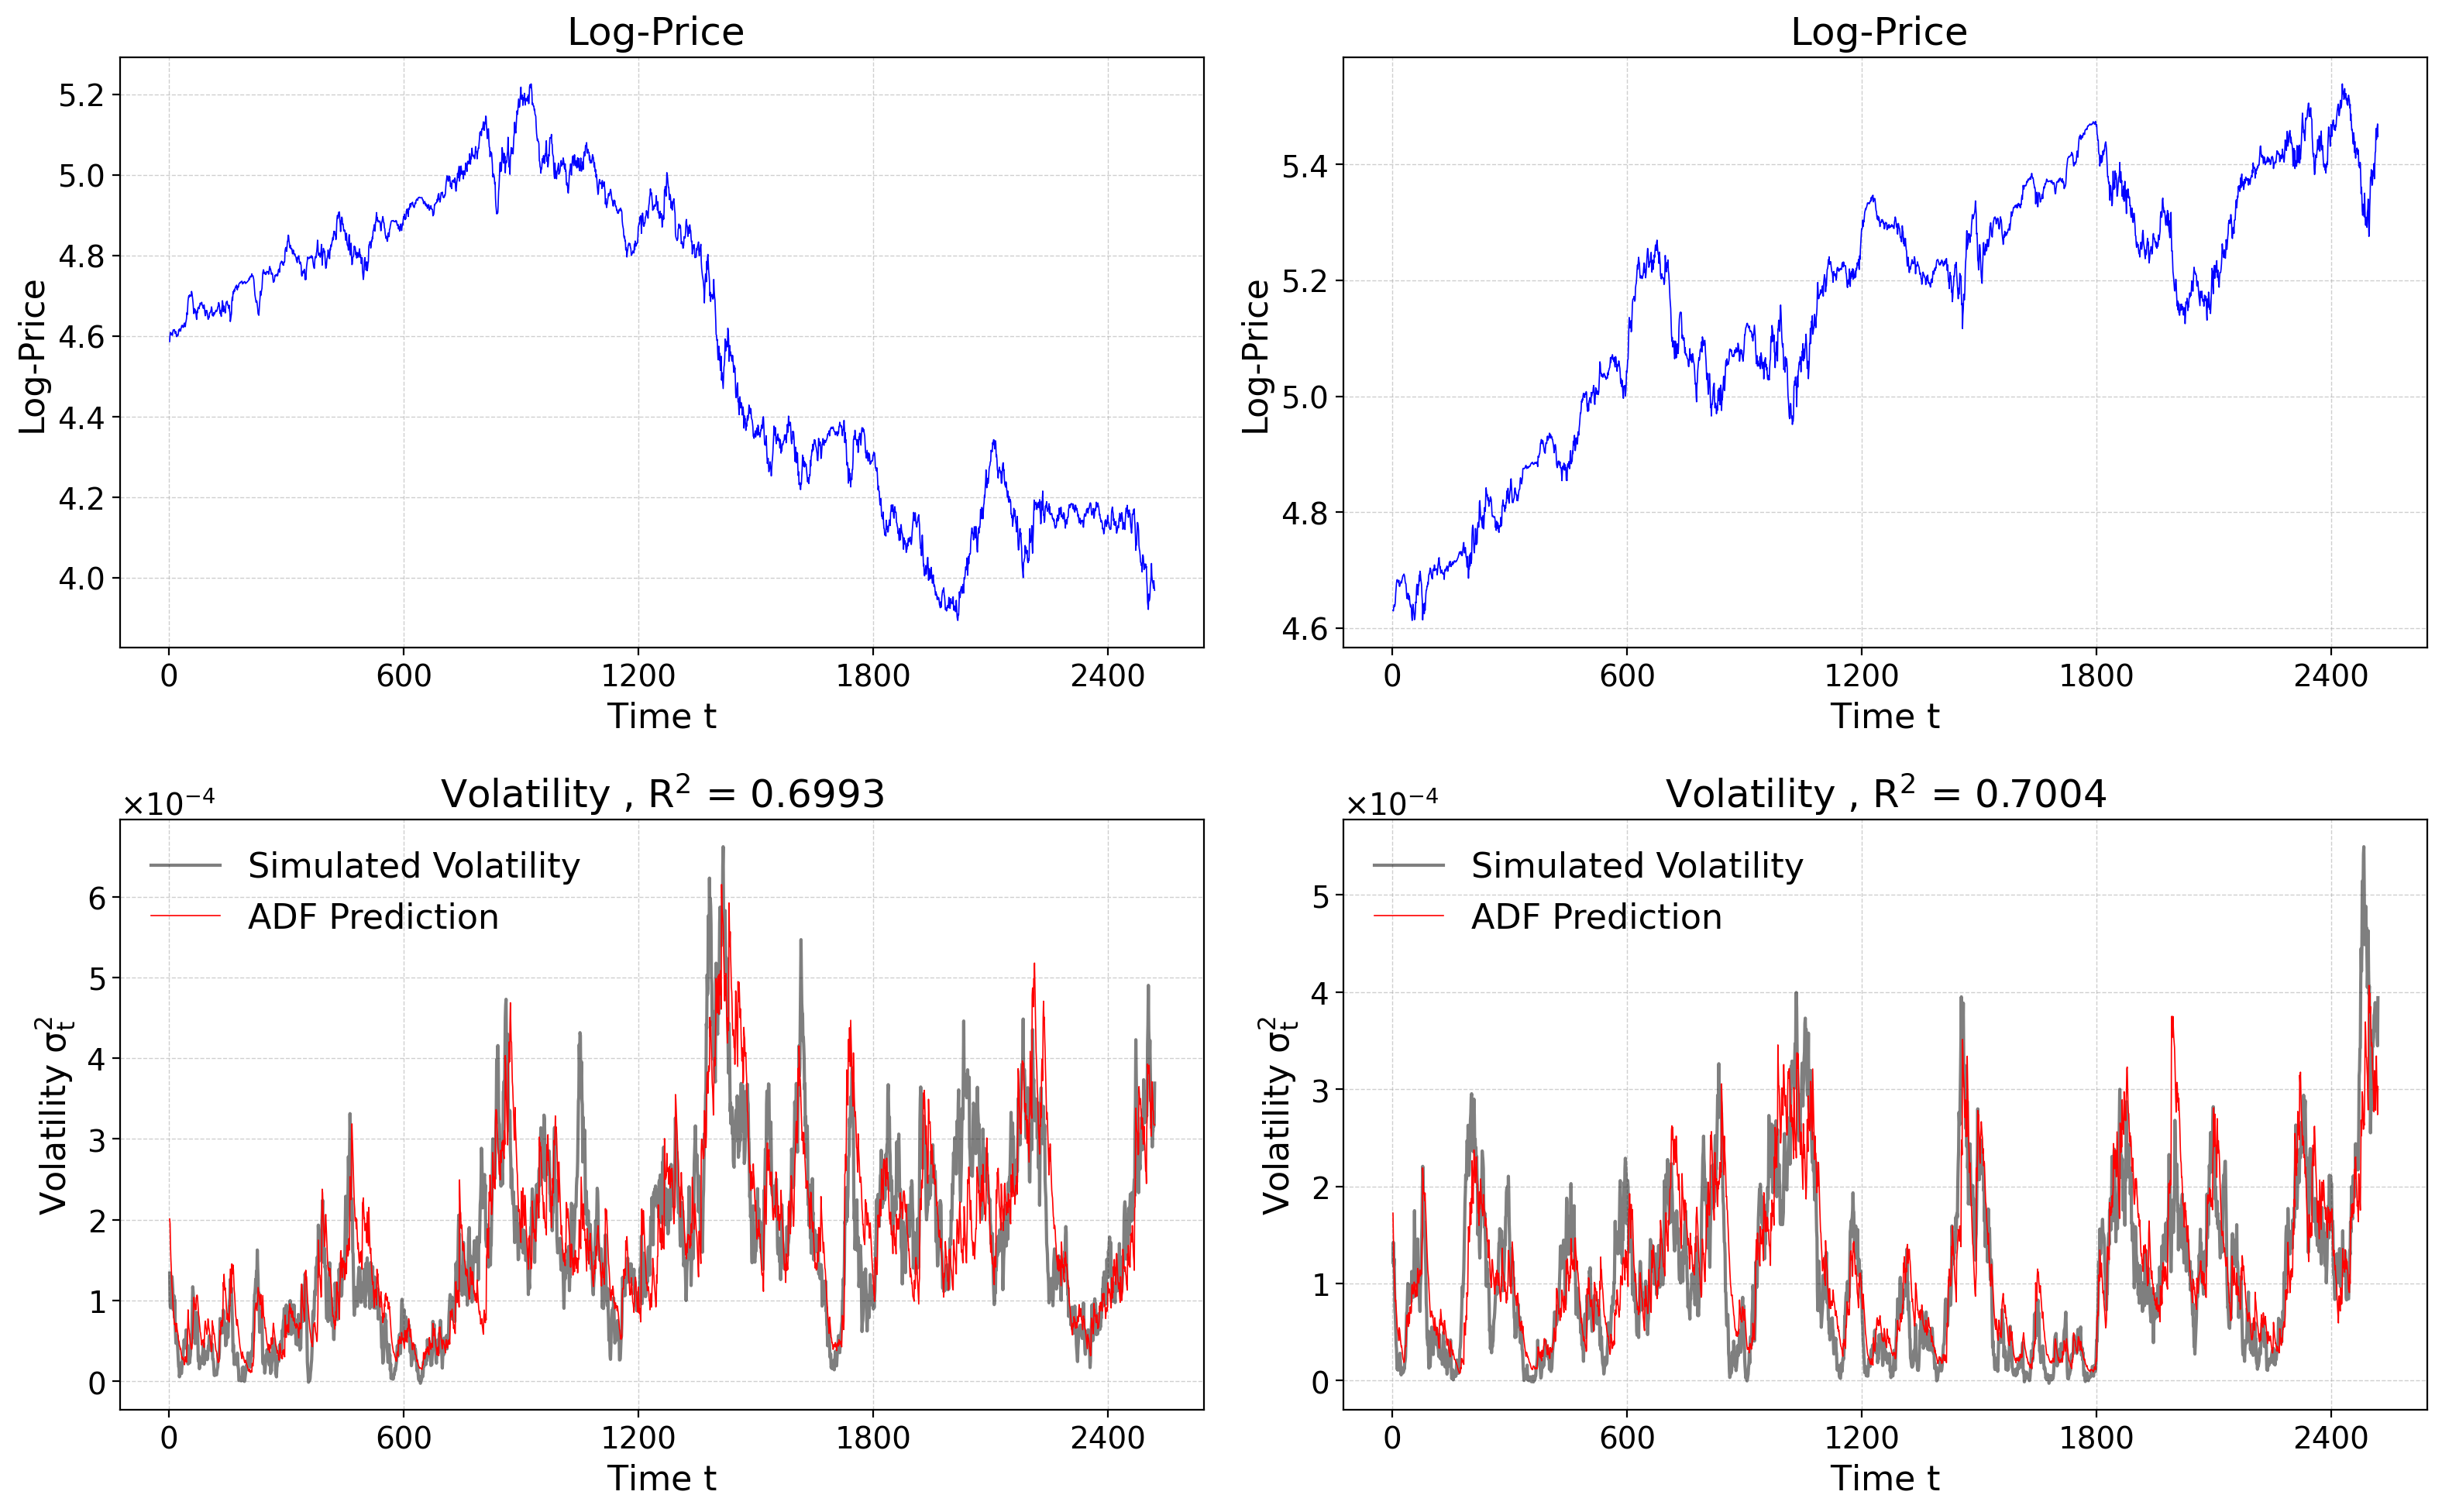

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator
import numpy as np

# --- Style configuration ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 14,
    'mathtext.default': 'regular'
})

# --- Create 2x2 layout ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x_tick_count = 5  # Number of ticks on x-axis

# ---------------- Top Left: Log-Price (In-Sample) ----------------
axes[0, 0].plot(t_observed[1:], price_in_sample[1:], color='b',
                linewidth=0.6, alpha=1.0)
axes[0, 0].set_title('Log-Price ', fontsize=18)
axes[0, 0].set_xlabel(r'Time $t$', fontsize=16)
axes[0, 0].set_ylabel('Log-Price', fontsize=16)
axes[0, 0].tick_params(axis='both', labelsize=14)
axes[0, 0].xaxis.set_major_locator(MaxNLocator(nbins=x_tick_count))
axes[0, 0].tick_params(axis='x', labelrotation=0)
axes[0, 0].grid(True, linestyle='--', alpha=0.6, linewidth=0.5)

# ---------------- Top Right: Log-Price (Out-of-Sample) ----------------
axes[0, 1].plot(t_observed[1:], price_out_of_sample[1:], color='b',
                linewidth=0.6, alpha=1.0)
axes[0, 1].set_title('Log-Price ', fontsize=18)
axes[0, 1].set_xlabel(r'Time $t$', fontsize=16)
axes[0, 1].set_ylabel('Log-Price', fontsize=16)
axes[0, 1].tick_params(axis='both', labelsize=14)
axes[0, 1].xaxis.set_major_locator(MaxNLocator(nbins=x_tick_count))
axes[0, 1].tick_params(axis='x', labelrotation=0)
axes[0, 1].grid(True, linestyle='--', alpha=0.6, linewidth=0.5)

# ---------------- Bottom Left: Volatility (In-Sample) ----------------
axes[1, 0].plot(t_observed[1:], vol_observed_in_sample[1:], label='Simulated Volatility',
                color='black', alpha=0.5, linewidth=1.5)
axes[1, 0].plot(t_observed[1:], ADF_in_sample[1:], label='ADF Prediction',
                color='r', linewidth=0.6, alpha=1.0)
axes[1, 0].set_title(f'Volatility , $R^2$ = {r2_ADF_in_sample:.4f}', fontsize=18)
axes[1, 0].set_xlabel(r'Time $t$', fontsize=16)
axes[1, 0].set_ylabel(r'Volatility $\sigma_t^2$', fontsize=16)
axes[1, 0].tick_params(axis='both', labelsize=14)
axes[1, 0].legend(fontsize=16, frameon=False, loc='upper left')
axes[1, 0].xaxis.set_major_locator(MaxNLocator(nbins=x_tick_count))
axes[1, 0].tick_params(axis='x', labelrotation=0)
axes[1, 0].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axes[1, 0].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
axes[1, 0].grid(True, linestyle='--', alpha=0.6, linewidth=0.5)

# ---------------- Bottom Right: Volatility (Out-of-Sample) ----------------
axes[1, 1].plot(t_observed[1:], vol_observed_out_of_sample[1:], label='Simulated Volatility',
                color='black', alpha=0.5, linewidth=1.5)
axes[1, 1].plot(t_observed[1:], ADF_out_of_sample[1:], label='ADF Prediction',
                color='r', linewidth=0.6, alpha=1.0)
axes[1, 1].set_title(f'Volatility , $R^2$ = {r2_ADF_out_of_sample:.4f}', fontsize=18)
axes[1, 1].set_xlabel(r'Time $t$', fontsize=16)
axes[1, 1].set_ylabel(r'Volatility $\sigma_t^2$', fontsize=16)
axes[1, 1].tick_params(axis='both', labelsize=14)
axes[1, 1].legend(fontsize=16, frameon=False, loc='upper left')
axes[1, 1].xaxis.set_major_locator(MaxNLocator(nbins=x_tick_count))
axes[1, 1].tick_params(axis='x', labelrotation=0)
axes[1, 1].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axes[1, 1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
axes[1, 1].grid(True, linestyle='--', alpha=0.6, linewidth=0.5)

# --- Final layout ---
plt.tight_layout()
plt.savefig(FIG_DIR / "Updated_ADF_Price_Volatility_4plots_cleaned3.png", dpi=300, bbox_inches='tight')
plt.show()

### 1.2 Stability of $Q_{t_{n-1}\mid t_{n-1}}$ and forgetting of the initial condition

Averages of $Q$ exclude the first `BURN` steps, so the plotted average is the
value used for the constant-$Q$ filter below.

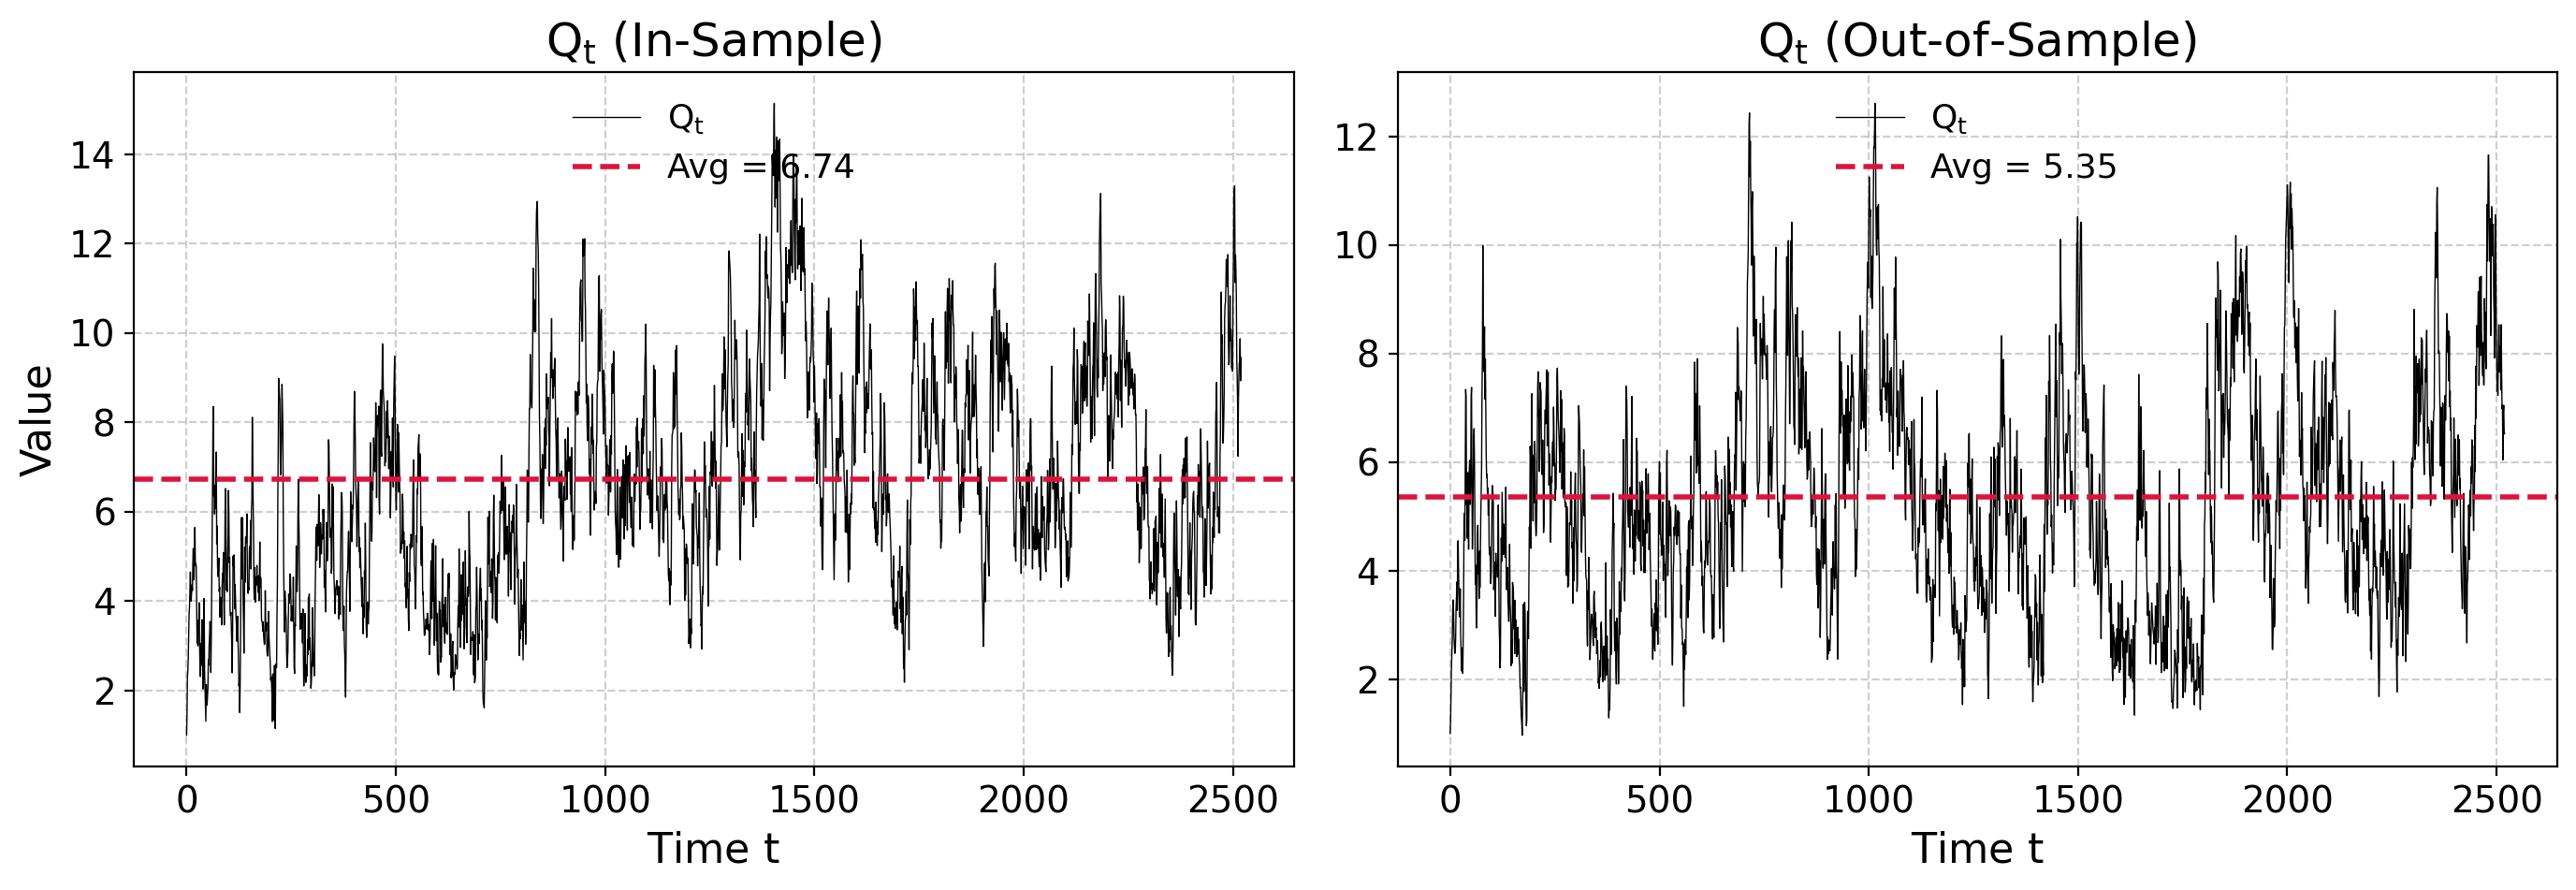

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Apply global styling
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'mathtext.default': 'regular'
})

# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- Plot for Q1 (In-Sample) ----------------
axes[0].plot((Q1), label=r'$Q_t$', color='black', linewidth=0.5)
axes[0].axhline(y=np.mean((Q1[BURN:])), color='crimson', linestyle='--', linewidth=2,
                label=fr'Avg = {np.mean((Q1[BURN:])):.2f}')
axes[0].set_title(r'$Q_t$ (In-Sample)', fontsize=18)
axes[0].set_xlabel(r'Time $t$', fontsize=16)
axes[0].set_ylabel('Value', fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)
axes[0].legend(fontsize=13, frameon=False, loc='upper center')
axes[0].grid(True, linestyle='--', alpha=0.6)

# ---------------- Plot for Q2 (Out-of-Sample) ----------------
axes[1].plot((Q2), label=r'$Q_t$', color='black', linewidth=0.5)
axes[1].axhline(y=np.mean((Q2[BURN:])), color='crimson', linestyle='--', linewidth=2,
                label=fr'Avg = {np.mean((Q2[BURN:])):.2f}')
axes[1].set_title(r'$Q_t$ (Out-of-Sample)', fontsize=18)
axes[1].set_xlabel(r'Time $t$', fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)
axes[1].legend(fontsize=13, frameon=False, loc='upper center')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Layout and export
plt.tight_layout()
plt.savefig(FIG_DIR / "Updated_HAVQt_in_and_outA21_cleaned4.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
Q_mean_in = Q_in[BURN:].mean()
Q_quad, Q_sqrt = stationary_Q(P_TRUE, h=H)
print(f"Path average of Q (in-sample, after {BURN} steps): {Q_mean_in:.3f}")
print(f"Stationary Q: quadratic (eqn:Qstationary) {Q_quad:.3f}, large-Q approximation {Q_sqrt:.3f}")
print(f"Minimum Q along both paths: {min(Q_in[BURN:].min(), Q_out[BURN:].min()):.3f}  (shape condition needs Q > 1/2)")
print(f"Skewness of Q in-sample: {pd.Series(Q_in[BURN:]).skew():.3f}")
RESULTS["Q"] = {"path_mean_in": Q_mean_in, "path_mean_out": Q_out[BURN:].mean(),
                "stationary_quadratic": Q_quad, "stationary_sqrt": Q_sqrt,
                "min": float(min(Q_in[BURN:].min(), Q_out[BURN:].min()))}

# Forgetting: filters started from very different initial densities on the same returns
starts = [(2.6, 0.5 * NU0), (3.0, NU0), (10.0, 2 * NU0), (50.0, 5 * NU0), (200.0, 0.2 * NU0)]
paths = np.array([adf_filter(Y_in, P_TRUE, m0, a0, H)[2] for a0, m0 in starts])
spread = paths.max(axis=0) - paths.min(axis=0)
for t in [1, 10, 50, 100, 250, 500, 1000]:
    print(f"step {t:5d}: spread of Q across initial conditions = {spread[t]:.2e}")
first_merge = int(np.argmax(spread < 1e-6))
print(f"Filters agree to within 1e-6 in Q after {first_merge} steps")
RESULTS["forgetting_steps_to_1e-6"] = first_merge

Path average of Q (in-sample, after 100 steps): 6.735
Stationary Q: quadratic (eqn:Qstationary) 5.335, large-Q approximation 5.579
Minimum Q along both paths: 0.967  (shape condition needs Q > 1/2)
Skewness of Q in-sample: 0.380
step     1: spread of Q across initial conditions = 4.12e+01
step    10: spread of Q across initial conditions = 1.75e+01
step    50: spread of Q across initial conditions = 1.55e+00
step   100: spread of Q across initial conditions = 1.10e-02
step   250: spread of Q across initial conditions = 2.42e-09
step   500: spread of Q across initial conditions = 0.00e+00
step  1000: spread of Q across initial conditions = 0.00e+00
Filters agree to within 1e-6 in Q after 196 steps


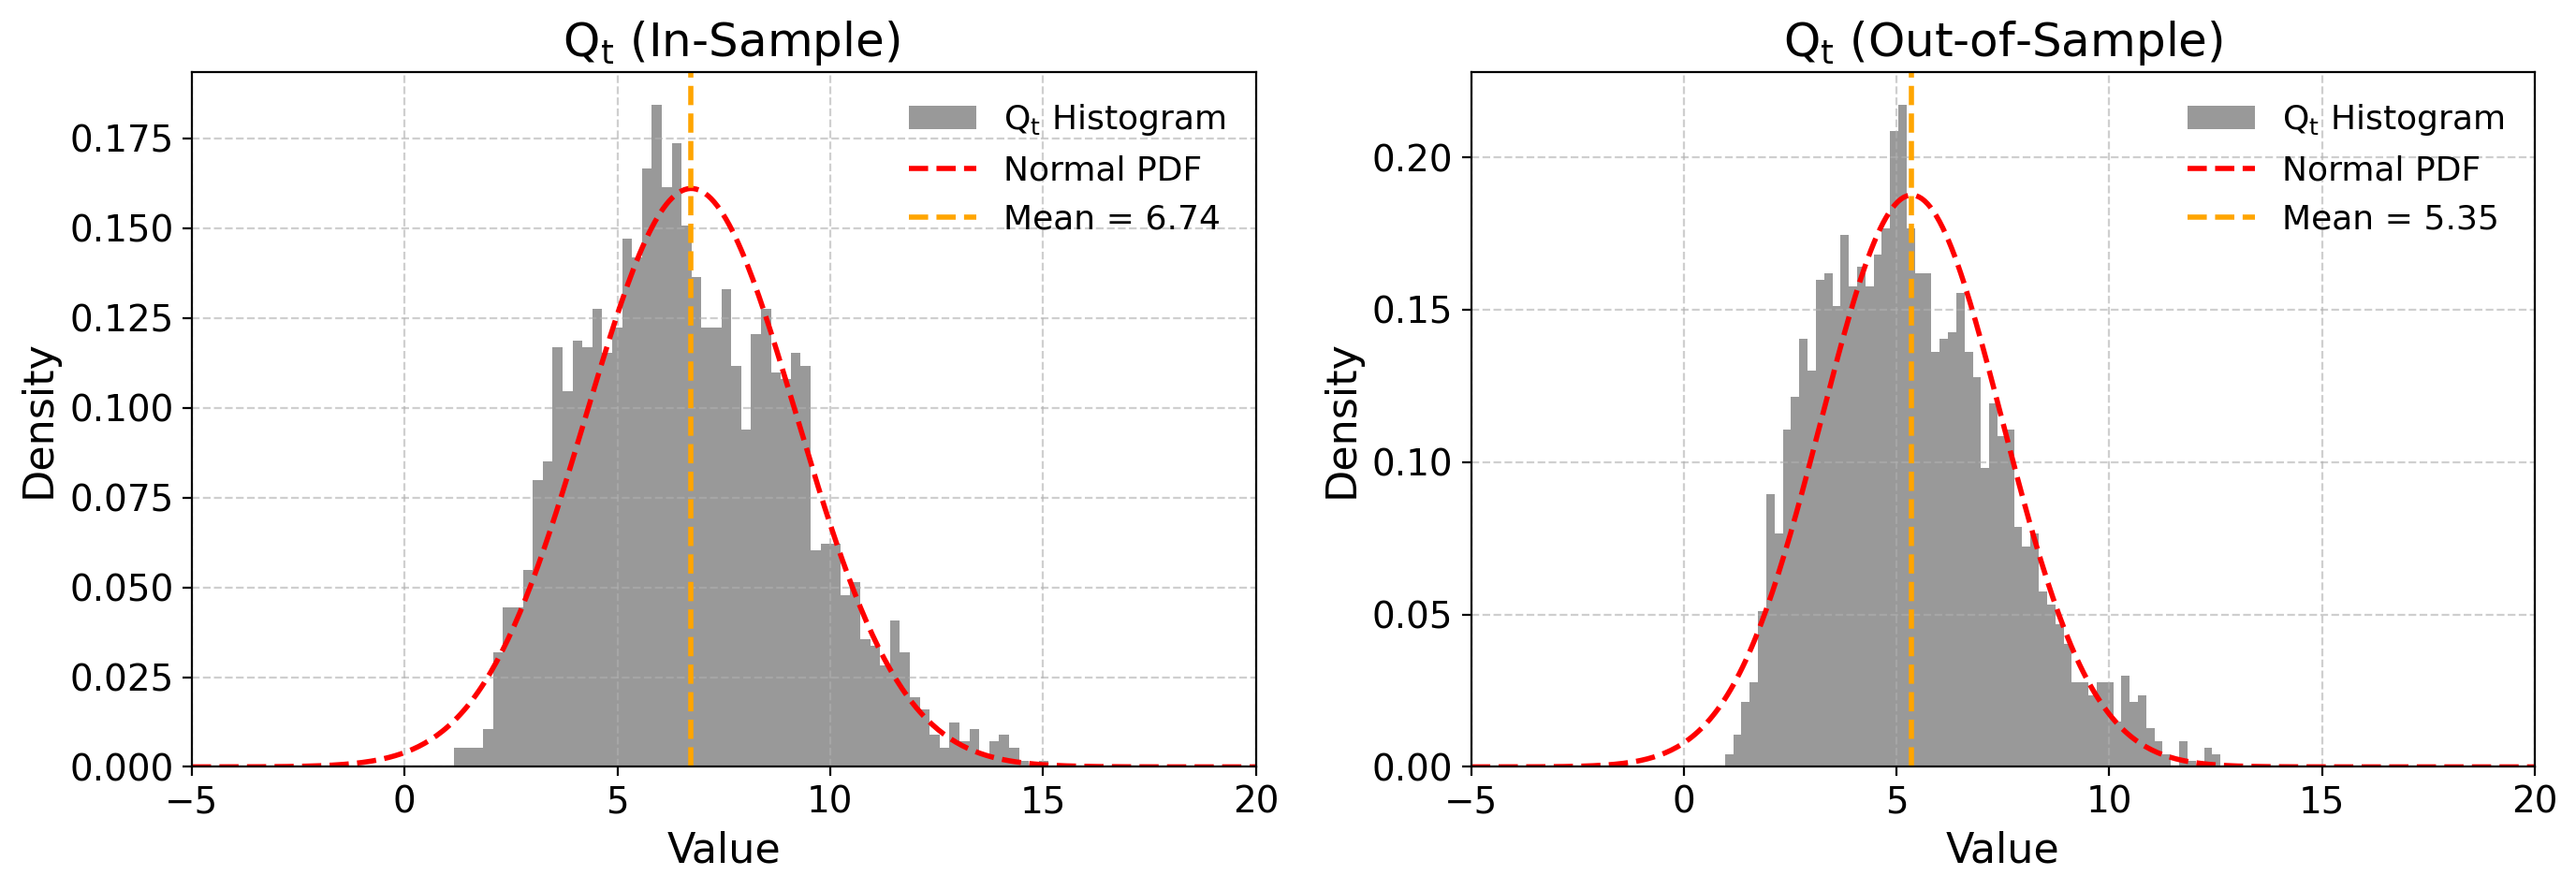

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Apply global styling
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'mathtext.default': 'regular'
})

# Transform Q1 and Q2
Q1_trans = (np.array(Q1[BURN:]) )
Q2_trans = (np.array(Q2[BURN:]) ) 

# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------- Histogram for Q1 (In-Sample) ----------
mu1 = np.mean(Q1_trans[2:])
std1 = np.std(Q1_trans[2:])
x1 = np.linspace(-5, 30, 500)

axes[0].hist(Q1_trans, bins=60, density=True, alpha=0.4, color='black', label=r'$Q_t$ Histogram')
axes[0].plot(x1, norm.pdf(x1, mu1, std1), 'r--', linewidth=2, label='Normal PDF')
axes[0].axvline(mu1, color='orange', linestyle='--', linewidth=2, label=fr'Mean = {mu1:.2f}')
axes[0].set_title(r' $Q_t$ (In-Sample)', fontsize=18)
axes[0].set_xlabel('Value', fontsize=16)
axes[0].set_ylabel('Density', fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)
axes[0].legend(fontsize=13, frameon=False, loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xlim(-5,20)

# ---------- Histogram for Q2 (Out-of-Sample) ----------
mu2 = np.mean(Q2_trans[2:])
std2 = np.std(Q2_trans[2:])
x2 = np.linspace(-5,30, 500)

axes[1].hist(Q2_trans, bins=60, density=True, alpha=0.4, color='black', label=r'$Q_t$ Histogram')
axes[1].plot(x2, norm.pdf(x2, mu2, std2), 'r--', linewidth=2, label='Normal PDF')
axes[1].axvline(mu2, color='orange', linestyle='--', linewidth=2, label=fr'Mean = {mu2:.2f}')
axes[1].set_title(r'$Q_t$ (Out-of-Sample)', fontsize=18)
axes[1].set_xlabel('Value', fontsize=16)
axes[1].set_ylabel('Density', fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)
axes[1].legend(fontsize=13, frameon=False, loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xlim(-5,20)

# Layout and export
plt.tight_layout()
plt.savefig(FIG_DIR / "HAVQt_Transformed_Histograms_with_NormalFit_MeanLines2.png", dpi=300, bbox_inches='tight')
plt.show()

### 1.3 Constant-$Q$ approximation (Lemma `lemma:pdvfromADF`)

$Q$ is the in-sample path mean of $Q_{t_{n-1}\mid t_{n-1}}$, used on both paths.

In [10]:
M_in  = adf_filter_constQ(Y_in,  P_TRUE, Q_mean_in, NU0, H)
M_out = adf_filter_constQ(Y_out, P_TRUE, Q_mean_in, NU0, H)
r2_const_in, r2_const_out = R2(nu_in[1:], M_in), R2(nu_out[1:], M_out)
print(f"Constant-Q: R^2 in {r2_const_in:.4f}, out {r2_const_out:.4f}")
print(f"Variable-Q: R^2 in {r2_var_in:.4f}, out {r2_var_out:.4f}")
RESULTS["sim_R2_constQ"] = {"in": r2_const_in, "out": r2_const_out, "Q": Q_mean_in}

# names used by the original plotting cell
ADF_in_sample2, ADF_out_of_sample2 = M_in, M_out
r2_ADF_in_sample2, r2_ADF_out_of_sample2 = r2_const_in, r2_const_out

Constant-Q: R^2 in 0.6935, out 0.6971
Variable-Q: R^2 in 0.6993, out 0.7004


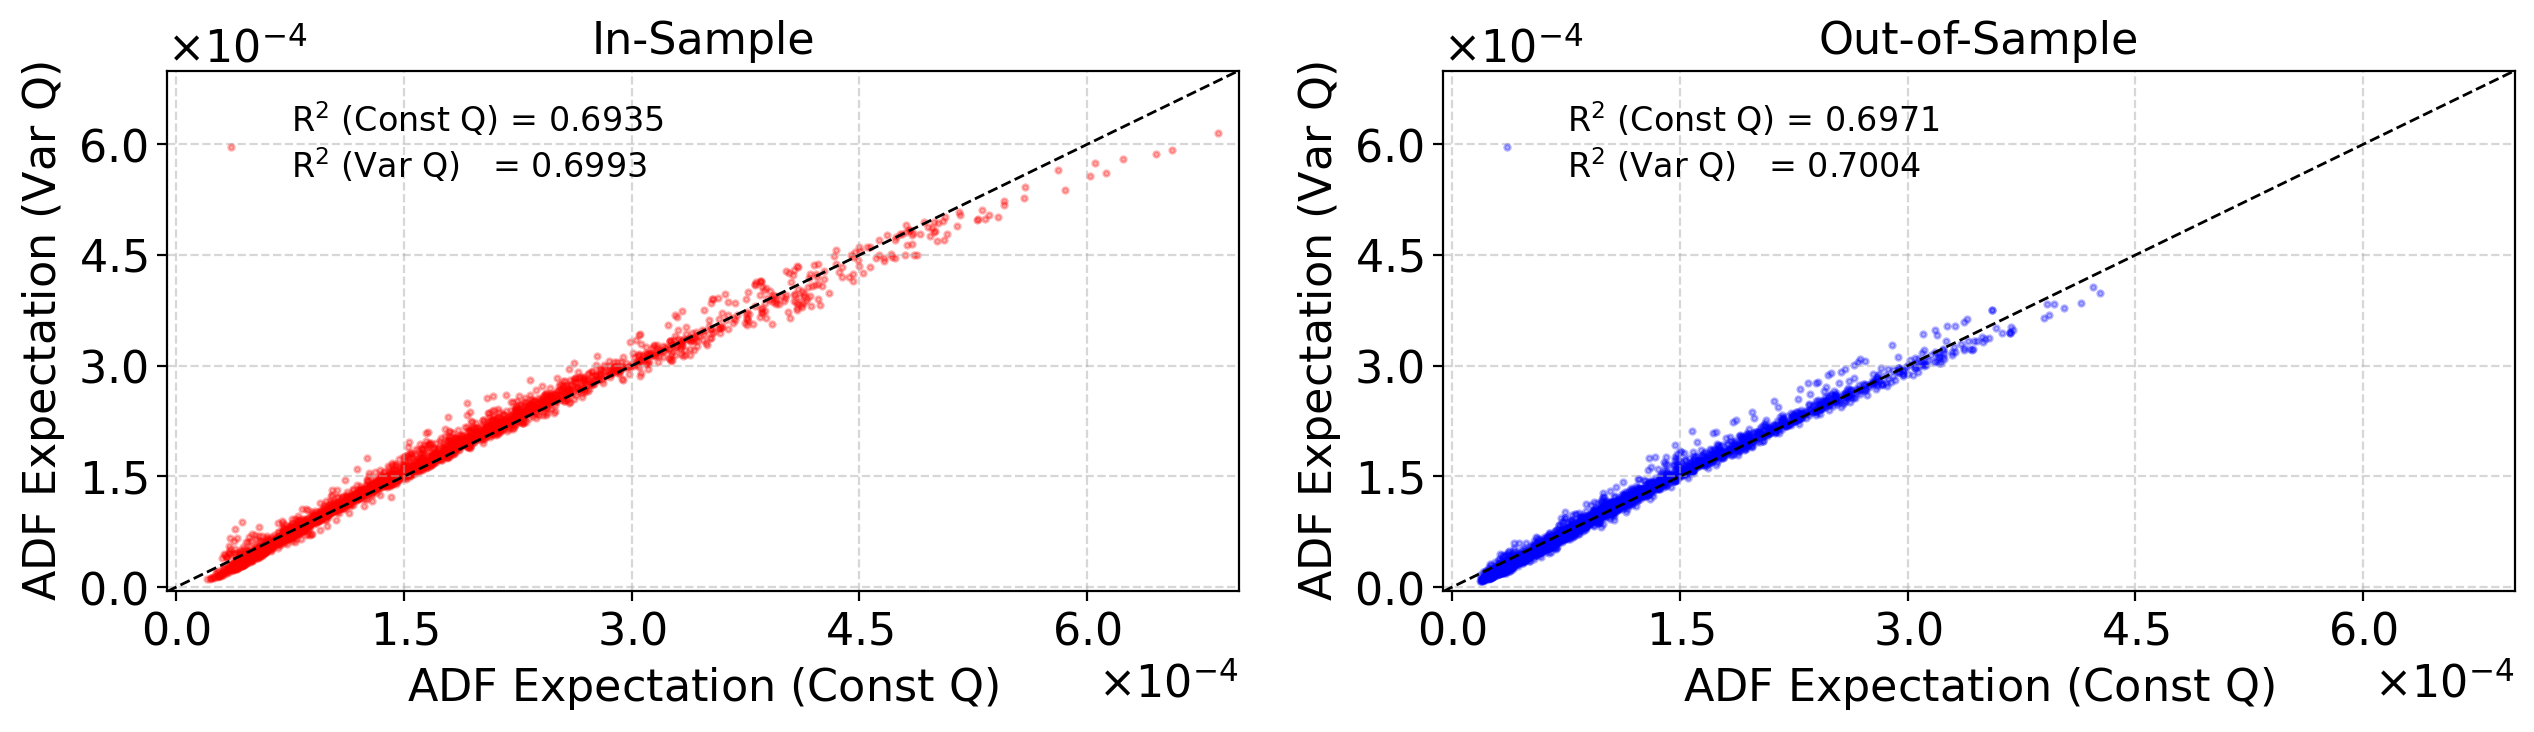

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator
import numpy as np

# --- Style Config: Match exact chart style ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'mathtext.default': 'regular'
})

# --- Figure and axis config ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Formatter ---
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))

# --- Shared plotting settings ---
point_size = 4
scatter_alpha = 0.3
line_width = 1.0
grid_kwargs = {'linestyle': '--', 'alpha': 0.5}

# --- Axis limits (shared across plots) ---
all_vals = np.concatenate([
    ADF_in_sample2, ADF_in_sample,
    ADF_out_of_sample2, ADF_out_of_sample
])
val_min, val_max = np.min(all_vals), np.max(all_vals)
buffer = 0.02 * (val_max - val_min)
lims = [val_min - buffer, val_max + buffer]

# ---------- In-sample ----------
axes[0].scatter(ADF_in_sample2, ADF_in_sample,
                color='red', alpha=scatter_alpha, s=point_size,
                label=fr'$R^2$ (Const $Q$) = {r2_ADF_in_sample2:.4f}' + '\n' +
                      fr'$R^2$ (Var $Q$)   = {r2_ADF_in_sample:.4f}')
axes[0].plot(lims, lims, 'k--', lw=line_width)

axes[0].set_title('In-Sample')
axes[0].set_xlabel(r'ADF Expectation (Const $Q$)')
axes[0].set_ylabel(r'ADF Expectation (Var $Q$)')
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=6))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))
axes[0].xaxis.set_major_formatter(formatter)
axes[0].yaxis.set_major_formatter(formatter)
axes[0].tick_params(axis='both', labelsize=16)
axes[0].legend(loc='upper left', frameon=False)
axes[0].grid(**grid_kwargs)

# ---------- Out-of-sample ----------
axes[1].scatter(ADF_out_of_sample2, ADF_out_of_sample,
                color='blue', alpha=scatter_alpha, s=point_size,
                label=fr'$R^2$ (Const $Q$) = {r2_ADF_out_of_sample2:.4f}' + '\n' +
                      fr'$R^2$ (Var $Q$)   = {r2_ADF_out_of_sample:.4f}')
axes[1].plot(lims, lims, 'k--', lw=line_width)

axes[1].set_title('Out-of-Sample')
axes[1].set_xlabel(r'ADF Expectation (Const $Q$)')
axes[1].set_ylabel(r'ADF Expectation (Var $Q$)')
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=6))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=6))
axes[1].xaxis.set_major_formatter(formatter)
axes[1].yaxis.set_major_formatter(formatter)
axes[1].tick_params(axis='both', labelsize=16)
axes[1].legend(loc='upper left', frameon=False)
axes[1].grid(**grid_kwargs)

# --- Final Layout & Save ---
plt.tight_layout()
plt.savefig(FIG_DIR / "Updated_ADF_const_vs_varQ_scatter2.png", dpi=300, bbox_inches='tight')
plt.show()

### 1.4 Comparison with a fitted PDV model over independent simulations (Figure `fig:correspondingpdvfit`)

The PDV model (eq. `PDVbasic`) is fitted once by least squares on the
in-sample path. Each experiment is a new independent path, on which we
evaluate the variable-$Q$ ADF at the true parameters, the constant-$Q$ ADF
with the in-sample $Q$, and the fitted PDV, all out of sample. $R^2$ on the
variance.

In [12]:
pdv_in = fit_pdv(Y_in, nu_in[1:], burn=BURN)
rng_exp = np.random.default_rng(SEED + 1)
rows = []
for k in range(N_EXPERIMENTS):
    _, nu_k, Y_k = simulate_heston(N_STEPS, P_TRUE, NU0, H, rng=rng_exp)
    E_k, _, _ = adf_filter(Y_k, P_TRUE, NU0, ALPHA0, H)
    M_k = adf_filter_constQ(Y_k, P_TRUE, Q_mean_in, NU0, H)
    S_k = pdv_predict(Y_k, pdv_in["lambda"], pdv_in["beta0"], pdv_in["beta1"], pdv_in["beta2"])
    rows.append({"ADF_varQ": R2(nu_k[1:], E_k), "ADF_constQ": R2(nu_k[1:], M_k), "PDV": R2(nu_k[1:], S_k)})
exp = pd.DataFrame(rows).sort_values("ADF_varQ", ascending=False).reset_index(drop=True)
print(exp.round(4).to_string())
print("\nMeans:", exp.mean().round(4).to_dict())
print("Variable-Q ADF beats fitted PDV in", int((exp.ADF_varQ > exp.PDV).sum()), "of", len(exp))
RESULTS["experiments"] = {"table": exp.to_dict(orient="list"), "mean": exp.mean().to_dict(),
                          "range": {c: [exp[c].min(), exp[c].max()] for c in exp}}

    ADF_varQ  ADF_constQ     PDV
0     0.8882      0.8653  0.8397
1     0.8186      0.8199  0.7954
2     0.8141      0.8140  0.7802
3     0.8120      0.8119  0.8040
4     0.8088      0.7913  0.7880
5     0.8084      0.7939  0.7871
6     0.8006      0.7850  0.7790
7     0.7908      0.7777  0.7591
8     0.7779      0.7522  0.7503
9     0.7773      0.7862  0.7708
10    0.7745      0.7606  0.7438
11    0.7565      0.7421  0.7023
12    0.7506      0.7507  0.7235
13    0.7478      0.7363  0.7229
14    0.7453      0.7365  0.7237
15    0.7413      0.7200  0.6974
16    0.7390      0.7293  0.6987
17    0.7221      0.7262  0.6961
18    0.7212      0.7182  0.7059
19    0.7100      0.6929  0.7007
20    0.7000      0.7075  0.6808
21    0.6790      0.6851  0.6818
22    0.6593      0.6353  0.6283
23    0.5970      0.5702  0.5829
24    0.3712      0.3884  0.4218

Means: {'ADF_varQ': 0.7405, 'ADF_constQ': 0.7319, 'PDV': 0.7186}
Variable-Q ADF beats fitted PDV in 23 of 25


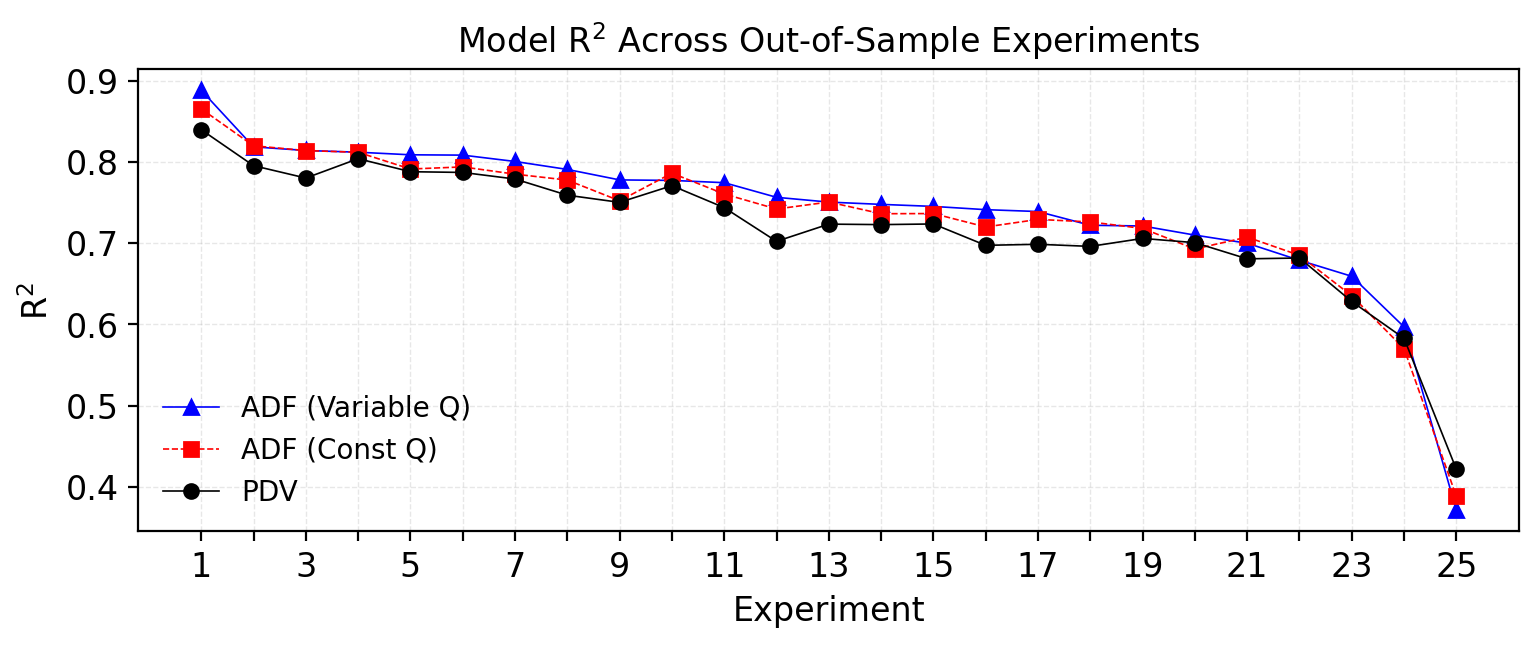

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data (computed above, sorted by the variable-Q ADF) ---
ADF_varQ = list(exp['ADF_varQ'].round(4))

PDV = list(exp['PDV'].round(4))

ADF_constQ = list(exp['ADF_constQ'].round(4))

x = np.arange(1, len(PDV) + 1)


# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.plot(x, ADF_varQ, '^-', label='ADF (Variable Q)', color='b',
        linewidth=0.6, markersize=5)
ax.plot(x, ADF_constQ, 's--', label='ADF (Const Q)', color='r',
        linewidth=0.6, markersize=5)
ax.plot(x, PDV, 'o-', label='PDV', color='k',
        linewidth=0.6, markersize=5)

# --- Axis formatting ---
ax.set_xlabel("Experiment", fontsize=12)
ax.set_ylabel(r"$R^2$", fontsize=12)
ax.set_title("Model $R^2$ Across Out-of-Sample Experiments", fontsize=12)

# Ticks: show odd experiments only on x-axis, with horizontal labels
ax.set_xticks(x)
ax.set_xticklabels([str(i) if i % 2 != 0 else '' for i in x], rotation=0, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

# --- Grid and legend ---
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
ax.legend(fontsize=10, frameon=False, loc='lower left')

# --- Final layout ---
plt.tight_layout()
plt.savefig(FIG_DIR / "Model_Comparion_2.png", dpi=300, bbox_inches='tight')
plt.show()

### 1.5 PDV-based estimation of Heston parameters (Section `sec:pdvinversion`)

The PDV model fitted to the in-sample path above is compared with the values
the matching relations `eqn:coeffmatching` take at the true parameters (Table
`PDVADFequivalentparams`), and inverted (Table `PDVADFequivalentHestonparams`).

In [14]:
inv = pdv_inversion(pdv_in, P_TRUE["mu"], H)
at_true = pdv_coefficients_from_heston(P_TRUE, inv["Q"], H)

lam = pdv_in["lambda"]
tab = pd.DataFrame({
    "fitted": [pdv_in["beta0"], lam * pdv_in["beta1"], lam * pdv_in["beta2"], np.exp(-lam * H)],
    "at true parameters": [at_true["beta0"], at_true["lam_beta1"], at_true["lam_beta2"], at_true["K"]],
}, index=["beta0", "lambda*beta1", "lambda*beta2", "exp(-lambda h)"])
tab["rel. diff (%)"] = 100 * (tab["fitted"] / tab["at true parameters"] - 1)
print("Table PDVADFequivalentparams\n", tab.to_string(float_format=lambda v: f"{v:.4g}"))
print(f"\nInversion: B = {inv['B']:.3f}, Q = {inv['Q']:.3f}, psi = {inv['psi']:.4f}, rho*xi = {inv['rhoxi']:.3e}")
print(f"True rho*xi = {P_TRUE['rho'] * P_TRUE['xi']:.3e}")

tab2 = pd.DataFrame({"true": [P_TRUE[k] for k in ["kappa", "nu_bar", "xi", "rho"]],
                     "PDV-implied": [inv[k] for k in ["kappa", "nu_bar", "xi", "rho"]]},
                    index=["kappa", "nu_bar", "xi", "rho"])
tab2["rel. error (%)"] = 100 * (tab2["PDV-implied"] / tab2["true"] - 1)
print("\nTable PDVADFequivalentHestonparams\n", tab2.to_string(float_format=lambda v: f"{v:.4g}"))
print(f"\nPDV R^2 on the in-sample path: {R2(nu_in[1:], pdv_predict(Y_in, lam, pdv_in['beta0'], pdv_in['beta1'], pdv_in['beta2'])):.4f}")
print(f"Conditioning: 1-K = {1 - np.exp(-lam):.4f}, h*lambda*beta2 = {lam * pdv_in['beta2']:.4f}")
RESULTS["pdv_fit"] = pdv_in
RESULTS["pdv_table"] = tab.to_dict()
RESULTS["pdv_inversion"] = inv

Table PDVADFequivalentparams
                   fitted  at true parameters  rel. diff (%)
beta0          4.545e-05           2.571e-05          76.82
lambda*beta1   -0.000783          -0.0008045         -2.672
lambda*beta2     0.05321              0.0537        -0.9137
exp(-lambda h)    0.9265               0.935        -0.9137

Inversion: B = 9.205, Q = 7.705, psi = 0.9797, rho*xi = -7.619e-04
True rho*xi = -7.832e-04

Table PDVADFequivalentHestonparams
             true  PDV-implied  rel. error (%)
kappa    0.01091      0.01996           82.88
nu_bar 0.0001389    0.0001599           15.16
xi      0.001687     0.001622          -3.838
rho      -0.4644      -0.4698           1.162

PDV R^2 on the in-sample path: 0.7065
Conditioning: 1-K = 0.0735, h*lambda*beta2 = 0.0532


### 1.6 ADF-based estimation of Heston parameters (Table `heston_params`)

Fit the variable-$Q$ filter to the in-sample path (returns only as input, the
simulated variance as target, least squares on volatility), evaluate on the
out-of-sample path.

In [15]:
X0_SIM = to_vector({"kappa": 0.02, "nu_bar": 1e-4, "xi": 2e-3, "rho": -0.3})
t0 = time.time()
P_SIM_FIT, res_sim = fit_adf(Y_in, nu_in[1:], P_TRUE["mu"], NU0, X0_SIM, ALPHA0, H)
print(f"fit in {time.time() - t0:.1f}s, converged: {res_sim.success}")

E_fit_in,  _, _ = adf_filter(Y_in,  P_SIM_FIT, NU0, ALPHA0, H)
E_fit_out, _, _ = adf_filter(Y_out, P_SIM_FIT, NU0, ALPHA0, H)
r2_fit_in, r2_fit_out = R2(nu_in[1:], E_fit_in), R2(nu_out[1:], E_fit_out)
print(f"Calibrated filter: R^2 in {r2_fit_in:.4f}, out {r2_fit_out:.4f}")
print(f"Filter at true parameters: R^2 in {r2_var_in:.4f}, out {r2_var_out:.4f}")
for k in ["kappa", "nu_bar", "xi", "rho"]:
    print(f"  {k:7s} true {P_TRUE[k]: .4e}  estimate {P_SIM_FIT[k]: .4e}")
print(f"Feller ratio of the estimate: {feller_ratio(P_SIM_FIT):.3f}")
RESULTS["sim_fit"] = {"params": P_SIM_FIT, "R2_in": r2_fit_in, "R2_out": r2_fit_out,
                      "feller_ratio": feller_ratio(P_SIM_FIT)}

fit in 0.9s, converged: True
Calibrated filter: R^2 in 0.7071, out 0.7085
Filter at true parameters: R^2 in 0.6993, out 0.7004
  kappa   true  1.0913e-02  estimate  1.5517e-02
  nu_bar  true  1.3889e-04  estimate  1.0625e-04
  xi      true  1.6865e-03  estimate  1.7663e-03
  rho     true -4.6440e-01  estimate -4.5631e-01
Feller ratio of the estimate: 1.057


### 1.7 Standard errors: true sampling distribution and parametric bootstrap (Appendix D)

(i) Simulate `N_BOOT` paths from the **true** parameters and fit on each.
(ii) Simulate `N_BOOT` paths from the **fitted** parameters and fit on each.

In [16]:
def sampling_distribution(p_sim, n_rep, seed, n_steps=N_STEPS, nu0=None, x0=None):
    rng_b = np.random.default_rng(seed)
    nu0 = p_sim["nu_bar"] if nu0 is None else nu0
    x0 = to_vector(p_sim) if x0 is None else x0
    out = np.array([simulate_and_fit(p_sim, n_steps, nu0, x0, rng_b, ALPHA0, H) for _ in range(n_rep)])
    return pd.DataFrame(out, columns=PARAM_NAMES)

t0 = time.time()
true_dist = sampling_distribution(P_TRUE, N_BOOT, SEED + 2, nu0=NU0, x0=X0_SIM)
boot_dist = sampling_distribution(P_SIM_FIT, N_BOOT, SEED + 3, nu0=NU0, x0=X0_SIM)
print(f"{2 * N_BOOT} fits in {time.time() - t0:.0f}s")

se_tab = pd.DataFrame({"True sampling distribution": true_dist.std(ddof=1),
                       "Parametric bootstrap": boot_dist.std(ddof=1)}).T
print("Table bootstrap_se\n", se_tab.to_string(float_format=lambda v: f"{v:.6f}"))

truth = report_vector(P_TRUE)
q_lo, q_hi = true_dist.quantile(0.025), true_dist.quantile(0.975)
print("\nTrue value inside the 95% interval of the true sampling distribution:",
      dict(zip(PARAM_NAMES, ((truth >= q_lo.values) & (truth <= q_hi.values)).tolist())))
RESULTS["se_sim"] = se_tab.to_dict()

# Table heston_params uses the true-sampling standard errors
heston_params = pd.DataFrame({"true": truth, "estimate": report_vector(P_SIM_FIT),
                              "se (true sampling)": true_dist.std(ddof=1).values}, index=PARAM_NAMES)
print("\nTable heston_params\n", heston_params.to_string(float_format=lambda v: f"{v:.4g}"))

200 fits in 210s
Table bootstrap_se
                               kappa  log_nu_bar       xi      rho
True sampling distribution 0.004902    0.316222 0.000234 0.077062
Parametric bootstrap       0.006151    2.874063 0.000258 0.080377

True value inside the 95% interval of the true sampling distribution: {'kappa': True, 'log_nu_bar': True, 'xi': True, 'rho': True}

Table heston_params
                true  estimate  se (true sampling)
kappa       0.01091   0.01552            0.004902
log_nu_bar   -8.882     -9.15              0.3162
xi         0.001687  0.001766           0.0002344
rho         -0.4644   -0.4563             0.07706


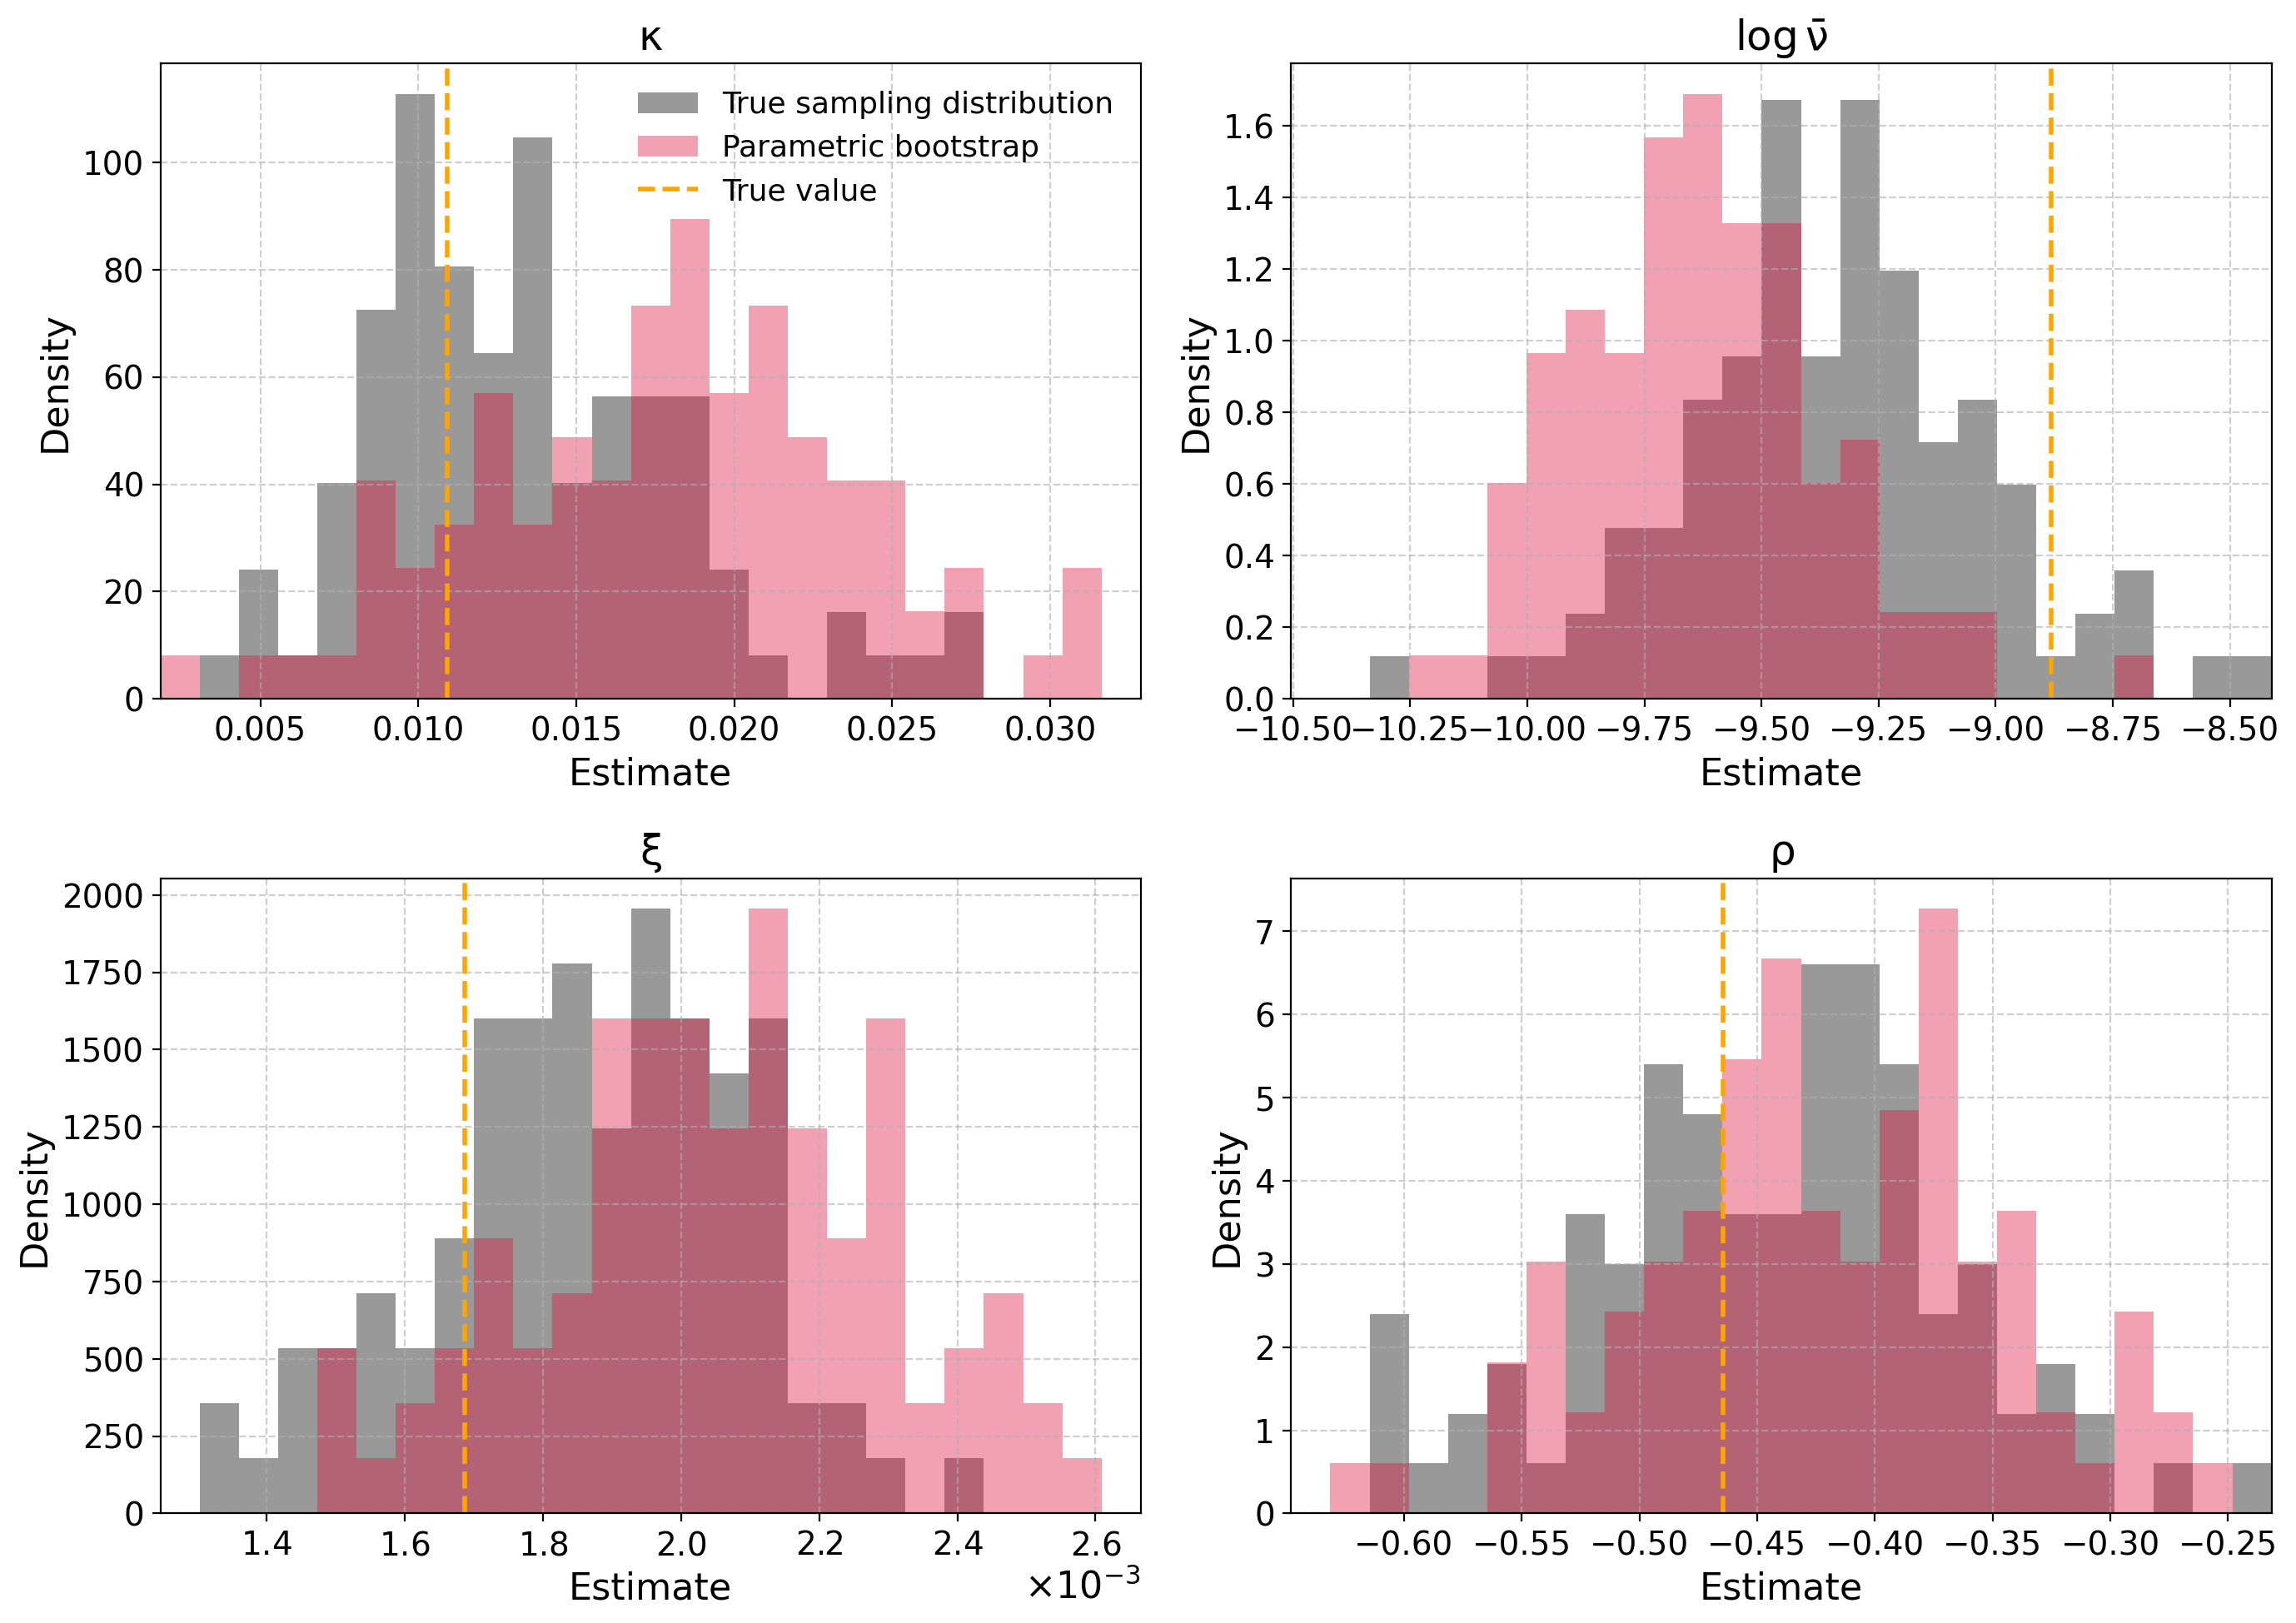

In [17]:
# Figure fig:parametricbootstrap
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update({
    'font.size': 14,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'mathtext.default': 'regular'
})

titles = {'kappa': r'$\kappa$', 'log_nu_bar': r'$\log\bar\nu$', 'xi': r'$\xi$', 'rho': r'$\rho$'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, name, true_value in zip(axes.ravel(), PARAM_NAMES, truth):
    t = np.asarray(true_dist[name], dtype=float)
    b = np.asarray(boot_dist[name], dtype=float)
    t, b = t[np.isfinite(t)], b[np.isfinite(b)]

    # Shared, robust range so outliers don't compress the plot
    both = np.concatenate([t, b])
    lo, hi = np.percentile(both, [0.5, 99.5])
    lo, hi = min(lo, true_value), max(hi, true_value)
    pad = 0.05 * (hi - lo)
    lo, hi = lo - pad, hi + pad
    bins = np.linspace(lo, hi, 26)

    n_out = np.sum((both < lo) | (both > hi))

    ax.hist(t, bins=bins, density=True, alpha=0.4, color='black', label='True sampling distribution')
    ax.hist(b, bins=bins, density=True, alpha=0.4, color='crimson', label='Parametric bootstrap')
    ax.axvline(true_value, color='orange', linestyle='--', linewidth=2, label='True value')
    ax.set_xlim(lo, hi)

    ax.set_title(titles[name], fontsize=18)
    ax.set_xlabel('Estimate', fontsize=16)
    ax.set_ylabel('Density', fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    if name == 'xi':
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

axes[0, 0].legend(fontsize=13, frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig(FIG_DIR / "bootstrap_histograms.png", dpi=300, bbox_inches='tight')
plt.show()

## 2. Real data (Sections `subsec:realisedvolpred` and `subsec:vixpred`)

Daily S&P 500 closes (`SPX_OX`), Oxford–Man 5-minute realised variance
(`RVOL_5min`) and the VIX. In-sample period from January 2001 to December 2008 and out-of-sample period from January 2009 to
the end of the Oxford–Man data in June 2018. The exact dates are printed below and used in every chart title.

* Returns are **log-returns**, $Y_{t_n}=\log S_{t_n}-\log S_{t_{n-1}}$.
* **Realised volatility is predicted for the next day**, as in Guyon and
  Lekeufack's Table (next-day realised volatility): after the return of day
  $n$, $\mathbb{E}[\nu_{t_n}\mid\mathcal{Y}_{t_n}]$ is paired with the realised
  variance of day $n+1$. A same-day pairing would be unfair, because the
  close-to-close return of day $n$ overlaps the trading hours of that day's
  realised variance. In `OXMI_pred`, row $j$ holds the forecast made after day
  $j-1$.
* **The VIX is estimated for the same day**, as in Guyon and Lekeufack, who
  predict the current-day VIX: the estimate after the return of day $n$ is
  paired with the VIX at the close of day $n$. Both are known at that close, so
  this uses no future information. In `VIX_pred`, row $j$ holds the estimate
  after day $j$.
* All pairings use plain numpy arrays. 
* $\mu$ is estimated from the in-sample data 
* $R^2$ is computed on volatility (square roots).

In [18]:
data = pd.read_csv(DATA_PATH).dropna(axis=1, how="all").dropna(subset=["SPX_OX", "RVOL_5min", "VIX"])
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date").reset_index(drop=True)
data["Y"] = np.log(data["SPX_OX"]).diff()
data["RV"] = data["RVOL_5min"]                    # daily realised variance
data["VIXvar"] = (data["VIX"] / 100) ** 2 / 365   # Cboe convention, per calendar day
data = data.dropna(subset=["Y"]).reset_index(drop=True)

ins = data[(data.Date >= "2000-12-31") & (data.Date <= "2008-12-31")].reset_index(drop=True)
oos = data[(data.Date >= "2009-01-01") & (data.Date <= "2018-12-31")].reset_index(drop=True)
# period labels used in every chart title, taken from the data actually used
def period(df):
    return f"{df.Date.iloc[0]:%b %Y} – {df.Date.iloc[-1]:%b %Y}"
IN_PERIOD, OUT_PERIOD = period(ins), period(oos)
print(f"in-sample {ins.Date.iloc[0].date()} to {ins.Date.iloc[-1].date()} ({len(ins)} days)")
print(f"out-of-sample {oos.Date.iloc[0].date()} to {oos.Date.iloc[-1].date()} ({len(oos)} days)")

MU_HAT = ins["Y"].mean() / H
print(f"mu_hat = {MU_HAT:.3e} per day ({252 * MU_HAT:.3f} annualised)")
RESULTS["mu_hat"] = MU_HAT
RESULTS["sample_periods"] = {"in": [str(ins.Date.iloc[0].date()), str(ins.Date.iloc[-1].date()), len(ins)],
                             "out": [str(oos.Date.iloc[0].date()), str(oos.Date.iloc[-1].date()), len(oos)]}

# data frames with the column names used by the original plotting cells
df_2000_to_2009, df_after_2009 = ins.copy(), oos.copy()
for df in (df_2000_to_2009, df_after_2009):
    df["OXMI_RVOL_Rescaled"] = df["RV"]
    df["VIX_Rescaled"] = df["VIXvar"]

in-sample 2001-01-02 to 2008-12-31 (1999 days)
out-of-sample 2009-01-02 to 2018-06-27 (2388 days)
mu_hat = -1.893e-04 per day (-0.048 annualised)


In [19]:
def fit_and_score(target_col, x0, label, lead):
    # fit on in-sample, evaluate on both samples.
    # lead=1: the forecast made after day n is paired with the target of day n+1 (next-day)
    # lead=0: the estimate after day n is paired with the target of day n (same-day)
    # All arrays are plain numpy, so pairing is by position.
    Yi, Ti = ins["Y"].values, ins[target_col].values
    Yo, To = oos["Y"].values, oos[target_col].values
    n_i, n_o = len(Yi) - lead, len(Yo) - lead
    t0 = time.time()
    p_hat, res = fit_adf(Yi[:n_i], Ti[lead:], MU_HAT, Ti[0], x0, ALPHA0, H)
    Ei, _, Qi = adf_filter(Yi, p_hat, Ti[0], ALPHA0, H)
    Eo, _, Qo = adf_filter(Yo, p_hat, To[0], ALPHA0, H)
    r2i = R2(np.sqrt(Ti[lead:]), np.sqrt(Ei[:n_i]))
    r2o = R2(np.sqrt(To[lead:]), np.sqrt(Eo[:n_o]))
    print(f"[{label}] {'next-day' if lead else 'same-day'} target")
    print(f"[{label}] fit in {time.time() - t0:.1f}s, converged {res.success}")
    print(f"[{label}] R^2 in-sample {r2i:.4f}, out-of-sample {r2o:.4f}")
    print(f"[{label}] Feller ratio {feller_ratio(p_hat):.3f}")
    return p_hat, Ei, Eo, Qi, Qo, r2i, r2o

def bootstrap_real(p_hat, n_obs, seed, x0):
    rng_b = np.random.default_rng(seed)
    out = np.array([simulate_and_fit(p_hat, n_obs, p_hat["nu_bar"], x0, rng_b, ALPHA0, H)
                    for _ in range(N_BOOT)])
    return pd.DataFrame(out, columns=PARAM_NAMES).std(ddof=1)

def parameter_table(p_hat, se, c, label):
    ann = annualise(p_hat, days_per_year_var=c)
    tab = pd.DataFrame({"estimate": report_vector(p_hat), "bootstrap se": se.values}, index=PARAM_NAMES)
    print(f"\n[{label}] daily units (table)\n", tab.to_string(float_format=lambda v: f"{v:.4g}"))
    print(f"[{label}] nu_bar = {p_hat['nu_bar']:.4g}; annualised kappa = {ann['kappa']:.4g}, "
          f"nu_bar = {ann['nu_bar']:.4g}, xi = {ann['xi']:.4g}, rho = {ann['rho']:.4g}")
    return tab, ann

def lagged(E):
    # row j holds the forecast made after day j-1
    return np.r_[np.nan, E[:-1]]

### 2.1 Realised volatility (Table `heston_params2`)

In [20]:
X0_RV = to_vector({"kappa": 0.05, "nu_bar": 5e-5, "xi": 5e-3, "rho": -0.4})
P_RV, E_rv_in, E_rv_out, Q_rv_in, Q_rv_out, r2_rv_in, r2_rv_out = fit_and_score("RV", X0_RV, "RV", lead=1)
t0 = time.time()
SE_RV = bootstrap_real(P_RV, len(ins), SEED + 4, X0_RV)
print(f"bootstrap in {time.time() - t0:.0f}s")
tab_rv, ann_rv = parameter_table(P_RV, SE_RV, 252.0, "RV")
RESULTS["rv"] = {"params": P_RV, "annualised": ann_rv, "se": SE_RV.to_dict(),
                 "R2_in": r2_rv_in, "R2_out": r2_rv_out, "feller_ratio": feller_ratio(P_RV),
                 "Q_mean_in": float(Q_rv_in[BURN:].mean()), "Q_min_in": float(Q_rv_in[BURN:].min())}

# names used by the original plotting cells
df_2000_to_2009["OXMI_pred"] = lagged(E_rv_in)
df_after_2009["OXMI_pred"] = lagged(E_rv_out)
r2_ADFOXMI_in_sample, r2_ADFOXMI_out_of_sample = r2_rv_in, r2_rv_out

[RV] next-day target
[RV] fit in 0.8s, converged True
[RV] R^2 in-sample 0.7230, out-of-sample 0.6077
[RV] Feller ratio 0.385
bootstrap in 152s

[RV] daily units (table)
             estimate  bootstrap se
kappa        0.06745       0.02863
log_nu_bar    -9.912        0.2103
xi          0.004167       0.00184
rho          -0.3792       0.06114
[RV] nu_bar = 4.956e-05; annualised kappa = 17, nu_bar = 0.01249, xi = 1.05, rho = -0.3792


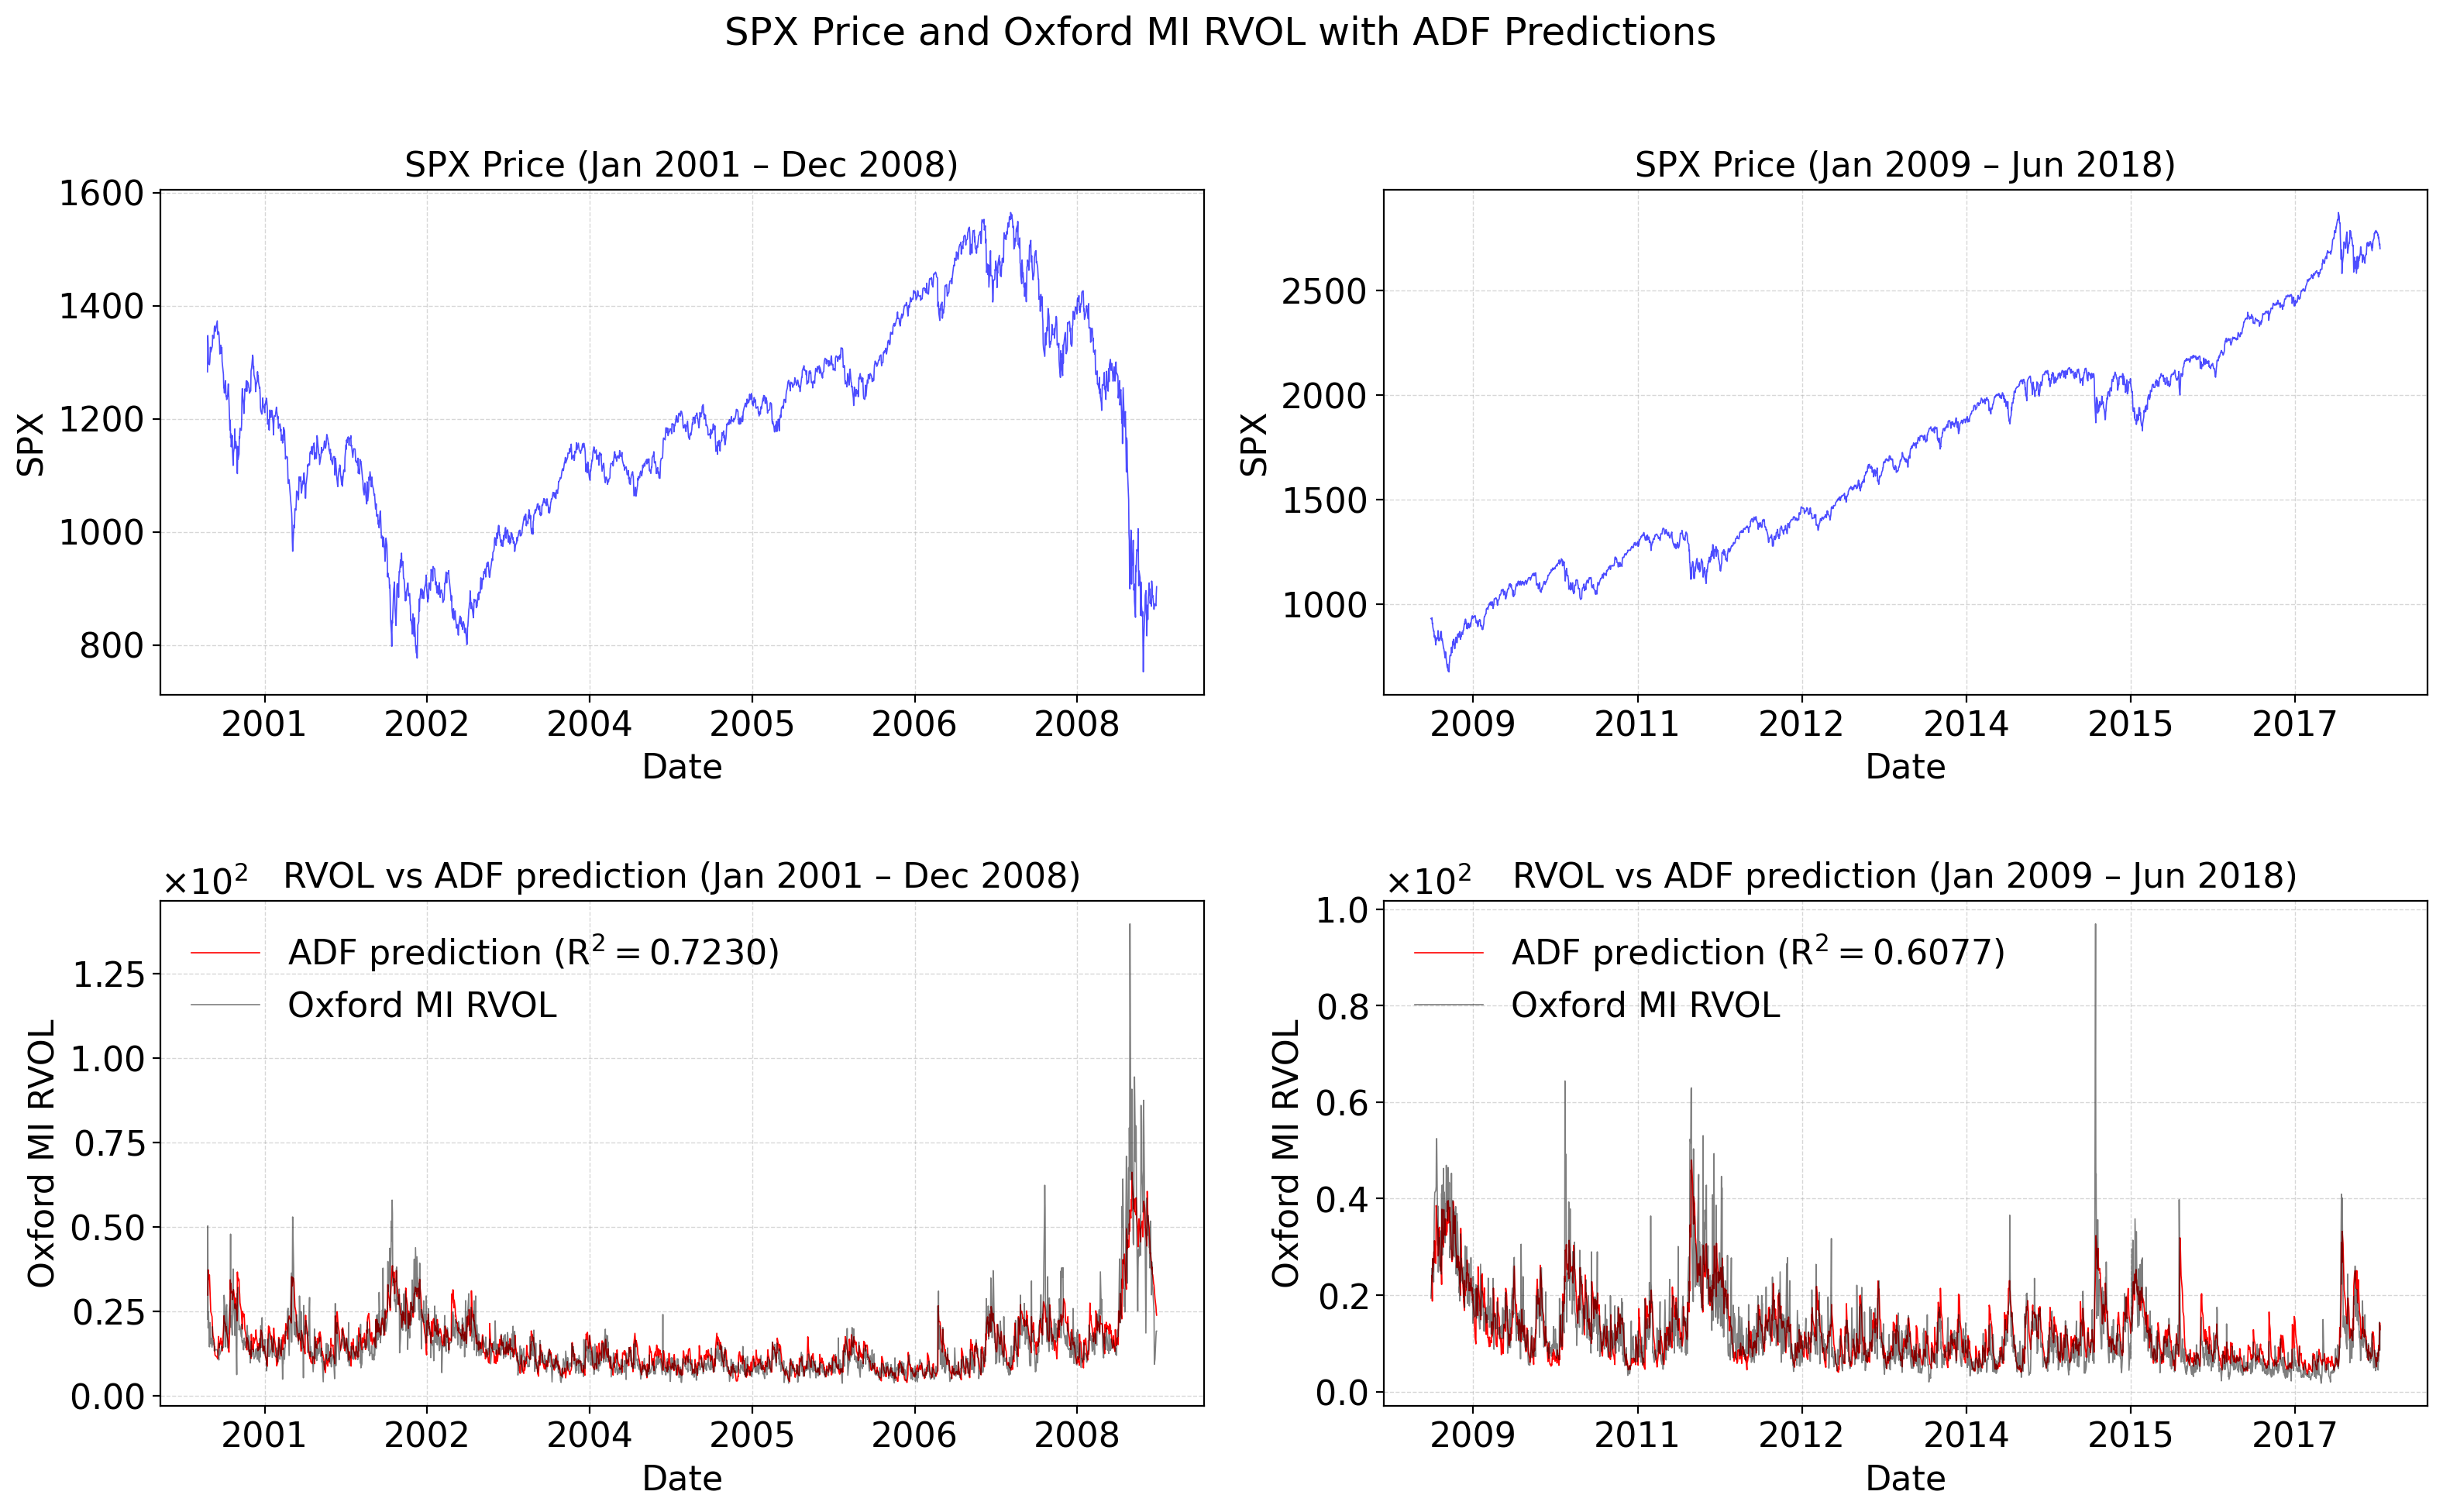

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter
import matplotlib.dates as mdates
import numpy as np

# --- Style configuration ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 14,
    'mathtext.default': 'regular'
})

# --- Plot formatting ---
figsize = (16, 10)
label_fontsize = 16
tick_fontsize = 16
legend_fontsize = 16
title_fontsize = 16
suptitle_fontsize = 18
line_width = 0.6
alpha_rvol = 0.5
alpha_spx = 0.7

# --- Volatility transformation ---
def annualize(vol_series):
    return np.sqrt(vol_series) * 100 * np.sqrt(252)

# --- Date formatting: year-only + 5 ticks ---
year_formatter = mdates.DateFormatter('%Y')
x_tick_count = 7

# --- Create 2x2 figure layout ---
fig, axes = plt.subplots(2, 2, figsize=figsize)

# --- Top row: SPX prices ---
for ax, df, title in zip(
    [axes[0, 0], axes[0, 1]],
    [df_2000_to_2009, df_after_2009],
    [f"SPX Price ({IN_PERIOD})", f"SPX Price ({OUT_PERIOD})"]
):
    ax.plot(df['Date'], df['SPX'], color='b', linewidth=line_width, alpha=alpha_spx)
    ax.set_title(title, fontsize=title_fontsize)
    ax.set_xlabel("Date", fontsize=label_fontsize)
    ax.set_ylabel("SPX", fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=x_tick_count))
    ax.xaxis.set_major_formatter(year_formatter)
    # Force x-tick labels to show and stay horizontal
    ax.tick_params(axis='x', labelrotation=0)

# --- Bottom row: Volatility prediction vs observed ---
def plot_vol_subplot(ax, df, r2, title):
    ax.plot(df['Date'], annualize(df['OXMI_pred']),
            label=rf'ADF prediction $(R^2 = {r2:.4f})$', color='r', linewidth=line_width)
    ax.plot(df['Date'], annualize(df['OXMI_RVOL_Rescaled']),
            label='Oxford MI RVOL', color='k', alpha=alpha_rvol, linewidth=line_width)

    ax.set_title(title, fontsize=title_fontsize)
    ax.set_xlabel("Date", fontsize=label_fontsize)
    ax.set_ylabel("Oxford MI RVOL", fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=x_tick_count))
    ax.xaxis.set_major_formatter(year_formatter)
    ax.tick_params(axis='x', labelrotation=0)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.legend(fontsize=legend_fontsize, frameon=False, loc='upper left')

plot_vol_subplot(axes[1, 0], df_2000_to_2009, r2_ADFOXMI_in_sample, f"RVOL vs ADF prediction ({IN_PERIOD})")
plot_vol_subplot(axes[1, 1], df_after_2009, r2_ADFOXMI_out_of_sample, f"RVOL vs ADF prediction ({OUT_PERIOD})")

# --- Final layout ---
fig.suptitle("SPX Price and Oxford MI RVOL with ADF Predictions", fontsize=suptitle_fontsize)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIG_DIR / "ADF_2x2_SPX_RVOL_Final_TicksHorizontal.png", dpi=300, bbox_inches='tight')
plt.show()

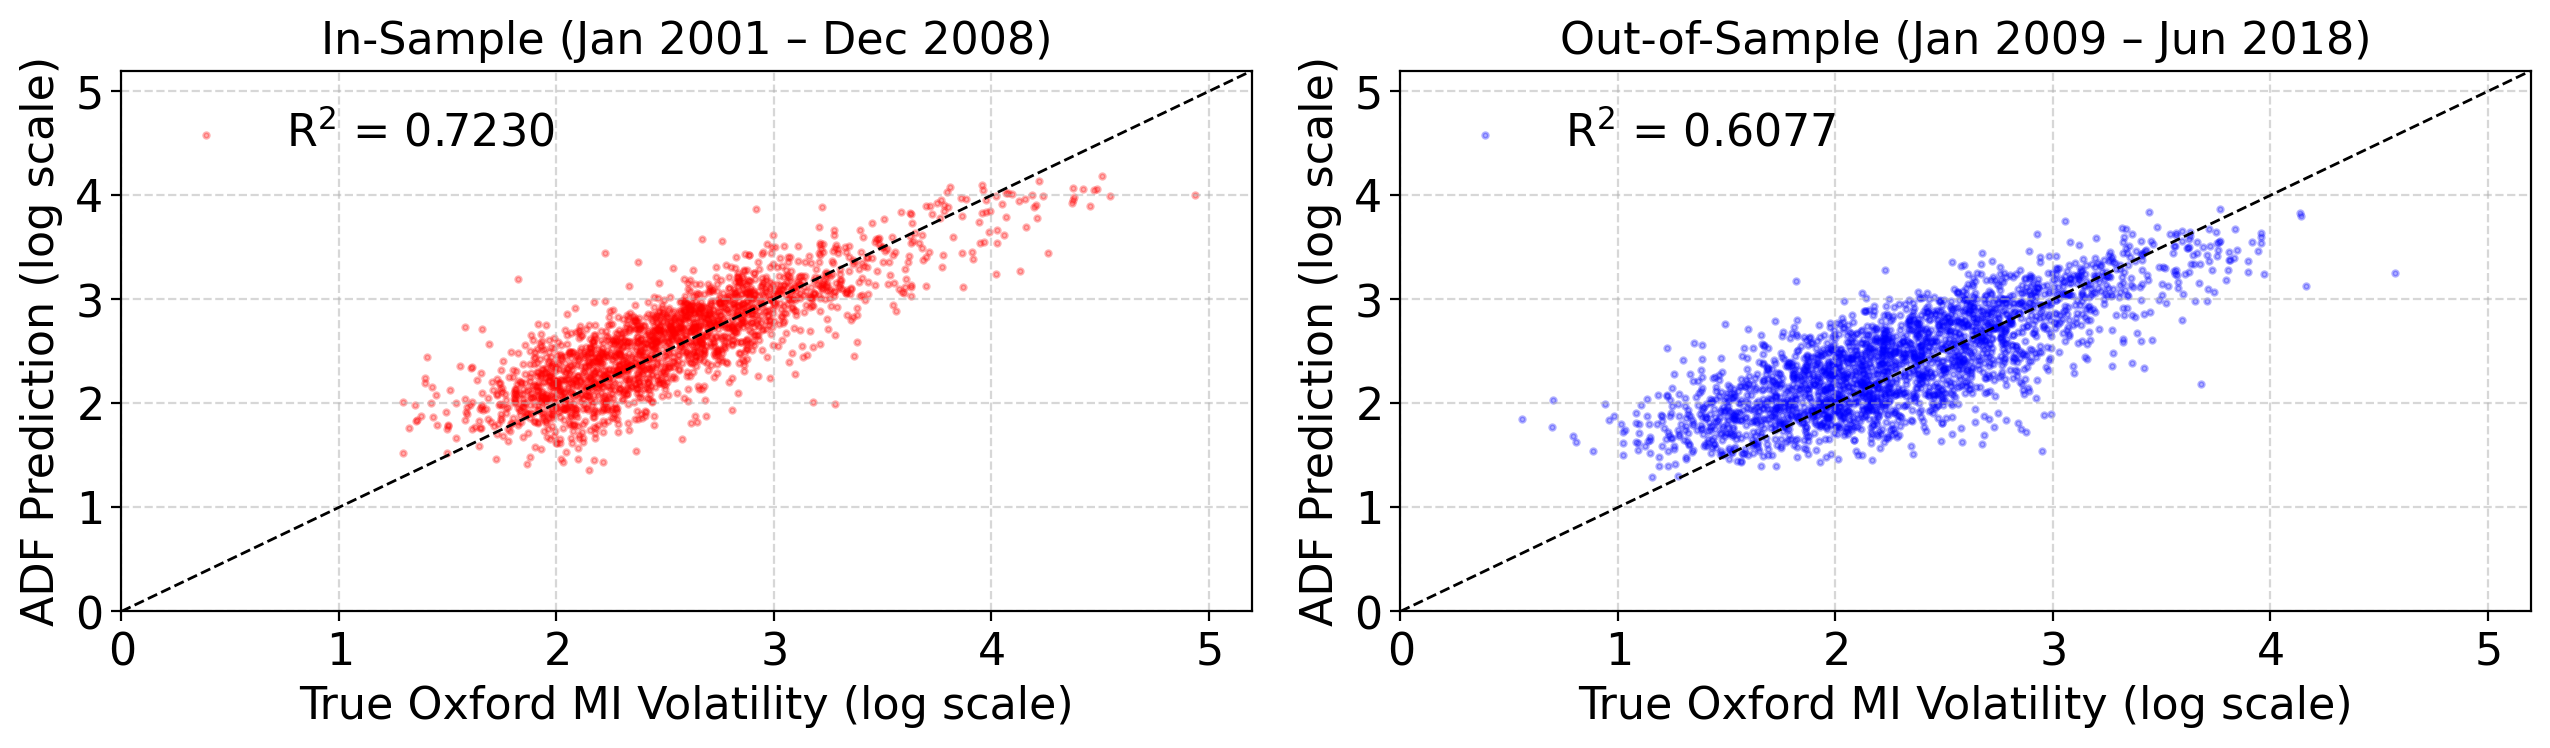

In [22]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator
import numpy as np

# Prepare log-transformed data
y_in  = np.log(np.sqrt(df_2000_to_2009['OXMI_pred']) * 100 * np.sqrt(252))
x_in  = np.log(np.sqrt(df_2000_to_2009['OXMI_RVOL_Rescaled']) * 100 * np.sqrt(252))
y_out = np.log(np.sqrt(df_after_2009['OXMI_pred']) * 100 * np.sqrt(252))
x_out = np.log(np.sqrt(df_after_2009['OXMI_RVOL_Rescaled']) * 100 * np.sqrt(252))

# Unified axis limits
xmin = min(x_in.min(), y_in.min(), x_out.min(), y_out.min())
xmax = max(x_in.max(), y_in.max(), x_out.max(), y_out.max())
buffer = 0.2
xlim = [0 , 5 + buffer]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Formatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))

# ---------- In-sample plot ----------
axes[0].scatter(x_in, y_in, color='red', alpha=0.3, s=4,
    label=fr'$R^2$ = {r2_ADFOXMI_in_sample:.4f}')
axes[0].plot(xlim, xlim, 'k--', lw=1)  # Diagonal line

axes[0].set_title(f'In-Sample ({IN_PERIOD})', fontsize=16)
axes[0].set_xlabel('True Oxford MI Volatility (log scale)', fontsize=16)
axes[0].set_ylabel('ADF Prediction (log scale)', fontsize=16)
axes[0].set_xlim(xlim)
axes[0].set_ylim(xlim)
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=6))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))
axes[0].tick_params(axis='both', labelsize=16)
axes[0].xaxis.set_major_formatter(formatter)
axes[0].yaxis.set_major_formatter(formatter)
axes[0].legend(fontsize=16, frameon=False, loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# ---------- Out-of-sample plot ----------
axes[1].scatter(x_out, y_out, color='blue', alpha=0.3, s=4,
    label=fr'$R^2$ = {r2_ADFOXMI_out_of_sample:.4f}')
axes[1].plot(xlim, xlim, 'k--', lw=1)  # Diagonal line

axes[1].set_title(f'Out-of-Sample ({OUT_PERIOD})', fontsize=16)
axes[1].set_xlabel('True Oxford MI Volatility (log scale)', fontsize=16)
axes[1].set_ylabel('ADF Prediction (log scale)', fontsize=16)
axes[1].set_xlim(xlim)
axes[1].set_ylim(xlim)
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=6))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=6))
axes[1].tick_params(axis='both', labelsize=16)
axes[1].xaxis.set_major_formatter(formatter)
axes[1].yaxis.set_major_formatter(formatter)
axes[1].legend(fontsize=16, frameon=False, loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Final layout
plt.tight_layout()
plt.savefig(FIG_DIR / "ADF_log_scatter_clean2.png", dpi=300, bbox_inches='tight')
plt.show()

### 2.2 VIX (Table `vix_model_params`)

Target $(\mathrm{VIX}/100)^2/365$, prediction $100\sqrt{365\,M}$. The fitted
parameters absorb the 30-day horizon, the variance risk premium and the
calendar/trading-day difference. In the two plotting cells below the only
change from the old notebook is `np.sqrt(252)` → `np.sqrt(365)`.

In [23]:
X0_VIX = to_vector({"kappa": 0.02, "nu_bar": 1.3e-4, "xi": 1.5e-3, "rho": -0.6})
P_VIX, E_vix_in, E_vix_out, Q_vix_in, Q_vix_out, r2_vix_in, r2_vix_out = fit_and_score("VIXvar", X0_VIX, "VIX", lead=0)
t0 = time.time()
SE_VIX = bootstrap_real(P_VIX, len(ins), SEED + 5, X0_VIX)
print(f"bootstrap in {time.time() - t0:.0f}s")
tab_vix, ann_vix = parameter_table(P_VIX, SE_VIX, 365.0, "VIX")
RESULTS["vix"] = {"params": P_VIX, "annualised": ann_vix, "se": SE_VIX.to_dict(),
                  "R2_in": r2_vix_in, "R2_out": r2_vix_out, "feller_ratio": feller_ratio(P_VIX)}

# names used by the original plotting cells
df_2000_to_2009["VIX_pred"] = E_vix_in      # same-day: row j holds the estimate after day j
df_after_2009["VIX_pred"] = E_vix_out
r2_ADFVIX_in_sample, r2_ADFVIX_out_of_sample = r2_vix_in, r2_vix_out

[VIX] same-day target
[VIX] fit in 0.8s, converged True
[VIX] R^2 in-sample 0.9116, out-of-sample 0.8556
[VIX] Feller ratio 3.038
bootstrap in 78s

[VIX] daily units (table)
             estimate  bootstrap se
kappa        0.01917      0.007247
log_nu_bar    -8.971        0.1431
xi          0.001267     0.0001655
rho          -0.5946       0.07826
[VIX] nu_bar = 0.0001271; annualised kappa = 4.832, nu_bar = 0.04638, xi = 0.3841, rho = -0.5946


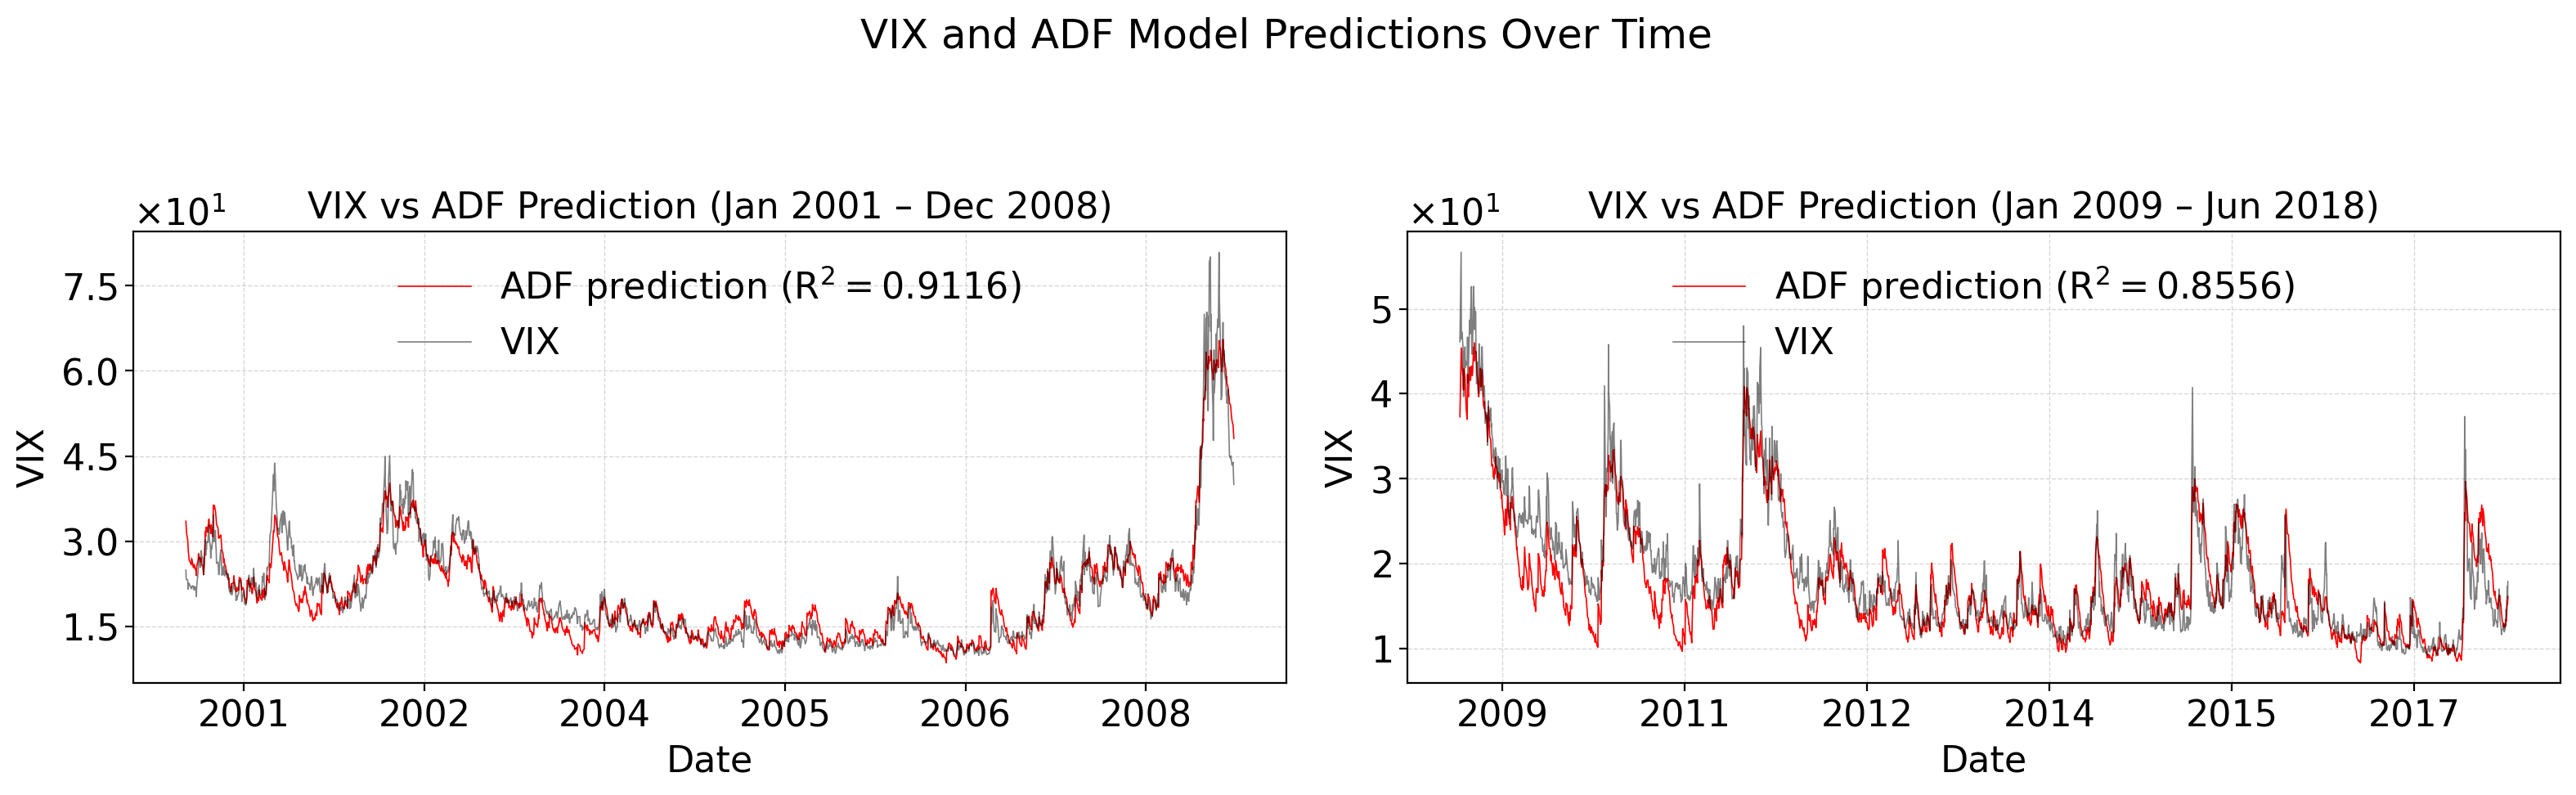

In [24]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter
import matplotlib.dates as mdates
import numpy as np

# --- Style configuration ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 14,
    'mathtext.default': 'regular'
})

# --- Plot formatting ---
figsize = (16, 5)  # Single row layout
label_fontsize = 16
tick_fontsize = 16
legend_fontsize = 16
title_fontsize = 16
suptitle_fontsize = 18
line_width = 0.6
alpha_vix = 0.5
alpha_spx = 0.7

# --- Volatility transformation ---
def annualize(vol_series):
    return np.sqrt(vol_series) * 100 * np.sqrt(365)

# --- Date formatting: year-only + 7 ticks ---
year_formatter = mdates.DateFormatter('%Y')
x_tick_count = 7

# --- Create 1x2 figure layout ---
fig, axes = plt.subplots(1, 2, figsize=figsize)

# --- VIX vs ADF predictions subplot function ---
def plot_vix_subplot(ax, df, r2, title, slice_from):
    ax.plot(df['Date'][slice_from:], annualize(df['VIX_pred'][slice_from:]),
            label=rf'ADF prediction $(R^2 = {r2:.4f})$', color='r', linewidth=line_width)
    ax.plot(df['Date'][slice_from:], annualize(df['VIX_Rescaled'][slice_from:]),
            label='VIX', color='black', alpha=alpha_vix, linewidth=line_width)

    ax.set_title(title, fontsize=title_fontsize)
    ax.set_xlabel("Date", fontsize=label_fontsize)
    ax.set_ylabel("VIX", fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=x_tick_count))
    ax.xaxis.set_major_formatter(year_formatter)
    ax.tick_params(axis='x', labelrotation=0)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.legend(fontsize=legend_fontsize, frameon=False, loc='upper center')

# --- Apply to both subplots ---
plot_vix_subplot(axes[0], df_2000_to_2009, r2_ADFVIX_in_sample, f"VIX vs ADF Prediction ({IN_PERIOD})", slice_from=10)
plot_vix_subplot(axes[1], df_after_2009, r2_ADFVIX_out_of_sample, f"VIX vs ADF Prediction ({OUT_PERIOD})", slice_from=10)

# --- Final layout ---
fig.suptitle("VIX and ADF Model Predictions Over Time", fontsize=suptitle_fontsize)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(FIG_DIR / "ADF_VIX_1x2_CleanPlot.png", dpi=300, bbox_inches='tight')
plt.show()

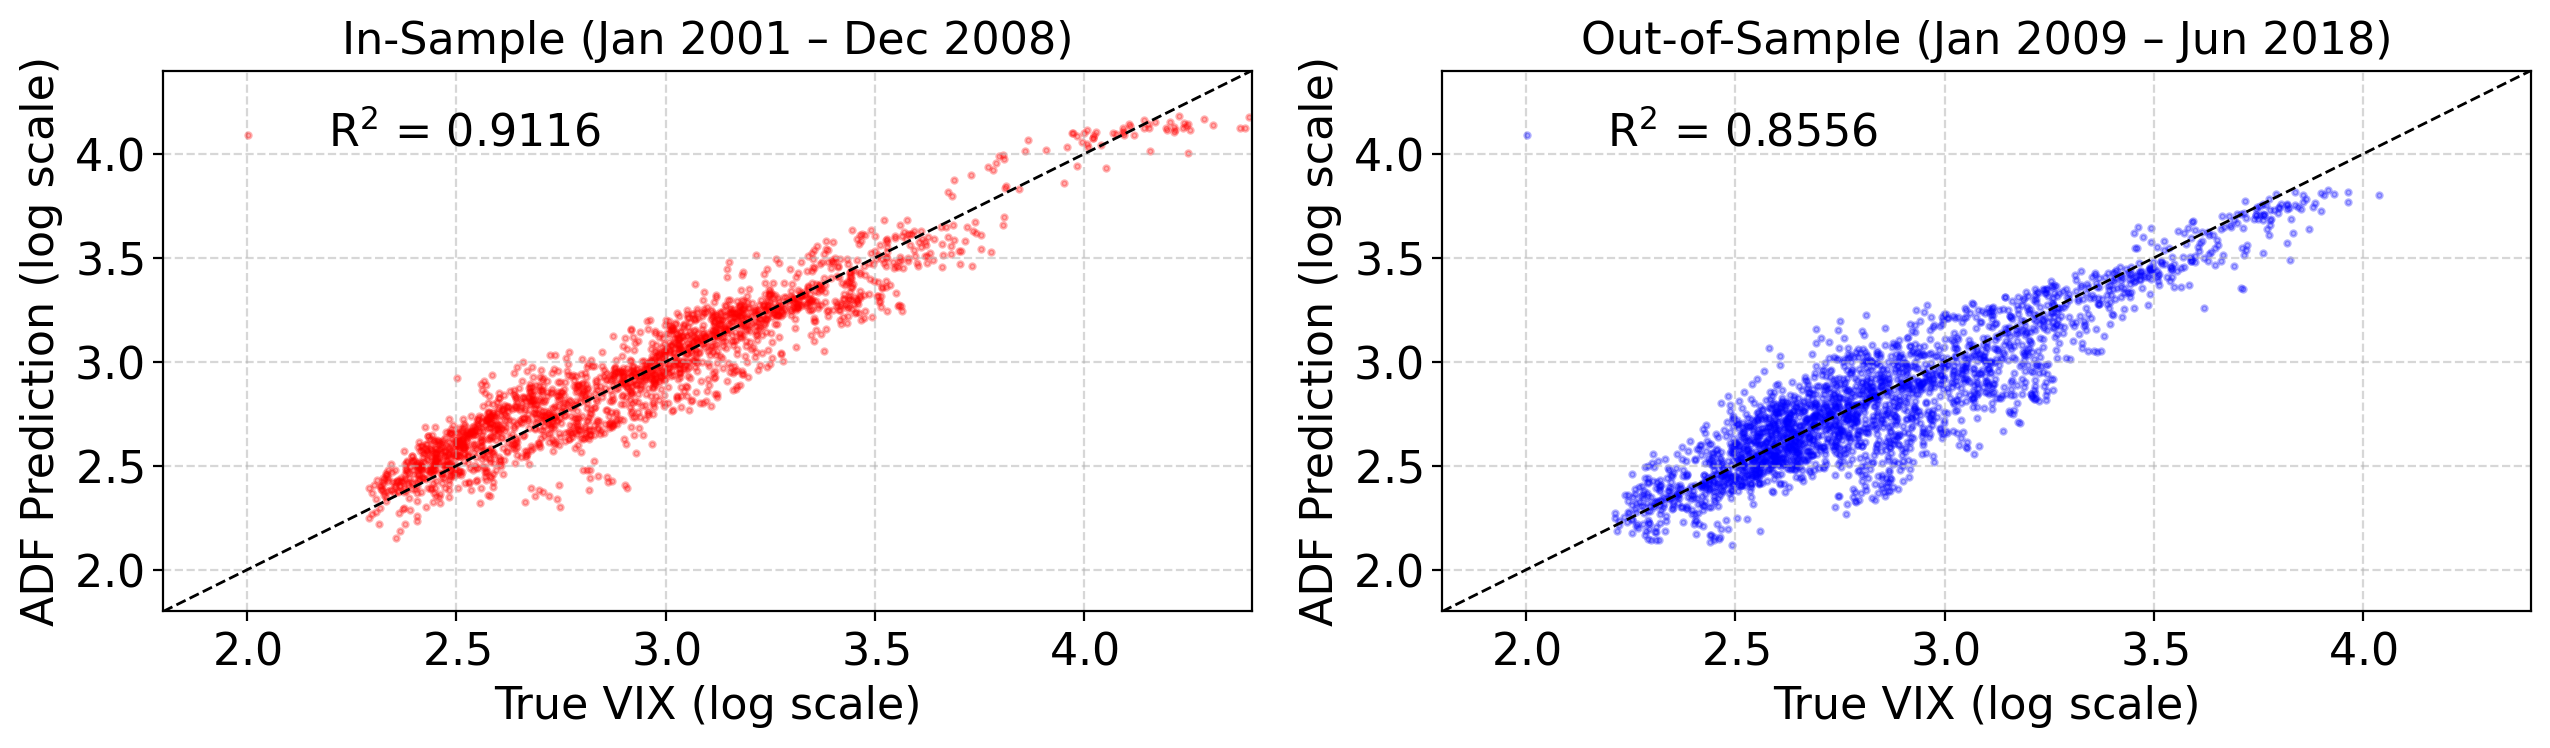

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator
import numpy as np

# --- Log-transform VIX predictions and true values ---
y_in  = np.log(safe_sqrt(df_2000_to_2009['VIX_pred'][10:]) * 100 * np.sqrt(365))
x_in  = np.log(safe_sqrt(df_2000_to_2009['VIX_Rescaled'][10:]) * 100 * np.sqrt(365))
y_out = np.log(safe_sqrt(df_after_2009['VIX_pred'][10:]) * 100 * np.sqrt(365))
x_out = np.log(safe_sqrt(df_after_2009['VIX_Rescaled'][10:]) * 100 * np.sqrt(365))

# --- Axis limits ---
xmin = min(x_in.min(), y_in.min(), x_out.min(), y_out.min())
xmax = max(x_in.max(), y_in.max(), x_out.max(), y_out.max())
buffer = 0.2
xlim = [1.8, 4.2 + buffer]

# --- Plot setup ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Formatter ---
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))

# ---------- In-sample ----------
axes[0].scatter(x_in, y_in, color='red', alpha=0.3, s=4,
    label=fr'$R^2$ = {r2_ADFVIX_in_sample:.4f}')
axes[0].plot(xlim, xlim, 'k--', lw=1)
axes[0].set_title(f'In-Sample ({IN_PERIOD})', fontsize=16)
axes[0].set_xlabel('True VIX (log scale)', fontsize=16)
axes[0].set_ylabel('ADF Prediction (log scale)', fontsize=16)
axes[0].set_xlim(xlim)
axes[0].set_ylim(xlim)
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=6))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))
axes[0].tick_params(axis='both', labelsize=16)
axes[0].xaxis.set_major_formatter(formatter)
axes[0].yaxis.set_major_formatter(formatter)
axes[0].legend(fontsize=16, frameon=False, loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# ---------- Out-of-sample ----------
axes[1].scatter(x_out, y_out, color='blue', alpha=0.3, s=4,
    label=fr'$R^2$ = {r2_ADFVIX_out_of_sample:.4f}')
axes[1].plot(xlim, xlim, 'k--', lw=1)
axes[1].set_title(f'Out-of-Sample ({OUT_PERIOD})', fontsize=16)
axes[1].set_xlabel('True VIX (log scale)', fontsize=16)
axes[1].set_ylabel('ADF Prediction (log scale)', fontsize=16)
axes[1].set_xlim(xlim)
axes[1].set_ylim(xlim)
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=6))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=6))
axes[1].tick_params(axis='both', labelsize=16)
axes[1].xaxis.set_major_formatter(formatter)
axes[1].yaxis.set_major_formatter(formatter)
axes[1].legend(fontsize=16, frameon=False, loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

# --- Final layout ---
plt.tight_layout()
plt.savefig(FIG_DIR / "ADFVIX_log_scatter_clean2.png", dpi=300, bbox_inches='tight')
plt.show()

## 3. Summary for the thesis and reproducibility record

Every number to update in Chapter 2, with versions and seeds. The same
content is written to `results_chapter2.json`.

In [26]:
print("=== Simulation (Section 4.1) ===")
print(f"Variable-Q ADF, true params:  R^2 in {r2_var_in:.4f}, out {r2_var_out:.4f}")
print(f"Constant-Q ADF (Q = {Q_mean_in:.2f}):  R^2 in {r2_const_in:.4f}, out {r2_const_out:.4f}")
print(f"Calibrated ADF:               R^2 in {r2_fit_in:.4f}, out {r2_fit_out:.4f}")
print(f"Stationary Q: {Q_quad:.2f} (quadratic), {Q_sqrt:.2f} (sqrt); path mean {Q_mean_in:.2f}; PDV-implied {inv['Q']:.2f}")
print(f"{N_EXPERIMENTS}-run means: {exp.mean().round(4).to_dict()}")
print("\n=== Realised volatility ===")
print(f"R^2 in {r2_rv_in:.4f}, out {r2_rv_out:.4f}; Feller ratio {feller_ratio(P_RV):.3f}")
print("\n=== VIX ===")
print(f"R^2 in {r2_vix_in:.4f}, out {r2_vix_out:.4f}; Feller ratio {feller_ratio(P_VIX):.3f}")
# Remark rem:leveragefallback: number of steps at which the fallback was used
def n_fb(Y, p, nu0):
    return adf_filter(Y, p, nu0, ALPHA0, H, return_fallbacks=True)[3]
rng_chk = np.random.default_rng(SEED + 1)
fb_exp = sum(n_fb(simulate_heston(N_STEPS, P_TRUE, NU0, H, rng=rng_chk)[2], P_TRUE, NU0)
             for _ in range(N_EXPERIMENTS))
fallbacks = {
    "simulation, true params (in, out)": [n_fb(Y_in, P_TRUE, NU0), n_fb(Y_out, P_TRUE, NU0)],
    "simulation, fitted params (in, out)": [n_fb(Y_in, P_SIM_FIT, NU0), n_fb(Y_out, P_SIM_FIT, NU0)],
    f"{N_EXPERIMENTS} comparison paths (total)": fb_exp,
    "RV fit (in, out)": [n_fb(ins["Y"].values, P_RV, ins["RV"].values[0]),
                         n_fb(oos["Y"].values, P_RV, oos["RV"].values[0])],
    "VIX fit (in, out)": [n_fb(ins["Y"].values, P_VIX, ins["VIXvar"].values[0]),
                          n_fb(oos["Y"].values, P_VIX, oos["VIXvar"].values[0])],
}
print("\nFallback steps (Remark rem:leveragefallback):", fallbacks)
RESULTS["fallback_steps"] = fallbacks

print("\nFeller ratios (Cozma–Reisinger needs > 3):",
      {"simulation": round(feller_ratio(P_TRUE), 3), "RV fit": round(feller_ratio(P_RV), 3),
       "VIX fit": round(feller_ratio(P_VIX), 3)})

RESULTS["environment"] = {"python": platform.python_version(), "numpy": np.__version__,
                          "scipy": scipy.__version__, "pandas": pd.__version__,
                          "matplotlib": matplotlib.__version__, "seed": SEED, "n_boot": N_BOOT,
                          "alpha0": ALPHA0, "run_date": time.strftime("%Y-%m-%d")}

def to_jsonable(o):
    if isinstance(o, dict):
        return {str(k): to_jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [to_jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    return o

Path("results_chapter2.json").write_text(json.dumps(to_jsonable(RESULTS), indent=2))
print("\nSaved results_chapter2.json and figures in", FIG_DIR.resolve())
print("Environment:", RESULTS["environment"])

=== Simulation (Section 4.1) ===
Variable-Q ADF, true params:  R^2 in 0.6993, out 0.7004
Constant-Q ADF (Q = 6.74):  R^2 in 0.6935, out 0.6971
Calibrated ADF:               R^2 in 0.7071, out 0.7085
Stationary Q: 5.33 (quadratic), 5.58 (sqrt); path mean 6.74; PDV-implied 7.71
25-run means: {'ADF_varQ': 0.7405, 'ADF_constQ': 0.7319, 'PDV': 0.7186}

=== Realised volatility ===
R^2 in 0.7230, out 0.6077; Feller ratio 0.385

=== VIX ===
R^2 in 0.9116, out 0.8556; Feller ratio 3.038

Fallback steps (Remark rem:leveragefallback): {'simulation, true params (in, out)': [0, 0], 'simulation, fitted params (in, out)': [0, 0], '25 comparison paths (total)': 0, 'RV fit (in, out)': [0, 0], 'VIX fit (in, out)': [0, 0]}

Feller ratios (Cozma–Reisinger needs > 3): {'simulation': 1.066, 'RV fit': 0.385, 'VIX fit': 3.038}

Saved results_chapter2.json and figures in /home/svosve/Desktop/figures
Environment: {'python': '3.12.3', 'numpy': '1.26.4', 'scipy': '1.11.4', 'pandas': '2.1.4', 'matplotlib': '3.6.3'